In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="700234OMk#",
    database="real_estate"
)

cursor = conn.cursor()

('New York', Decimal('2493319.74'))
('Phoenix', Decimal('2459961.76'))
('Los Angeles', Decimal('2442418.31'))
('Houston', Decimal('2436811.00'))
('Chicago', Decimal('2430677.90'))


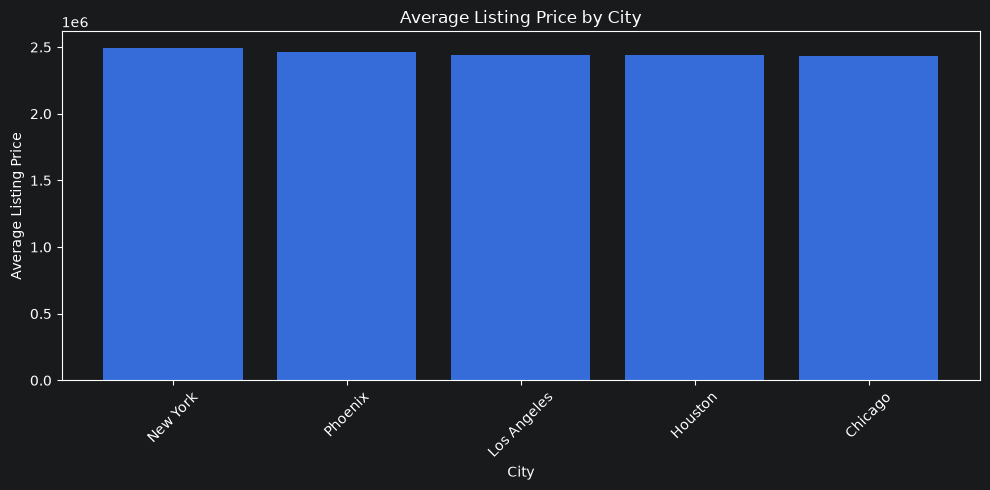

In [4]:
# Property & Pricing Analysis
#1. What is the average listing price by city?


#Coding

query = """
SELECT
    city,
    ROUND(AVG(price), 2) AS average_listing_price
FROM listings
GROUP BY city
ORDER BY average_listing_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


import pandas as pd

query = """
SELECT
    city,
    ROUND(AVG(price), 2) AS average_listing_price
FROM listings
GROUP BY city
ORDER BY average_listing_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

avg_price_df = pd.DataFrame(
    rows,
    columns=["City", "Average Listing Price"]
)

avg_price_df


#Display

import pandas as pd

query = """
SELECT
    city,
    ROUND(AVG(price), 2) AS average_listing_price
FROM listings
GROUP BY city
ORDER BY average_listing_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

avg_price_df = pd.DataFrame(
    rows,
    columns=["City", "Average Listing Price"]
)

avg_price_df


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(avg_price_df["City"], avg_price_df["Average Listing Price"])
plt.title("Average Listing Price by City")
plt.xlabel("City")
plt.ylabel("Average Listing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

('House', Decimal('796.04'))
('Apartment', Decimal('792.20'))
('Townhouse', Decimal('789.75'))
('Condo', Decimal('754.68'))
  Property Type Average Price per Sq. Ft.
0         House                    796.04
1     Apartment                    792.20
2     Townhouse                    789.75
3         Condo                    754.68


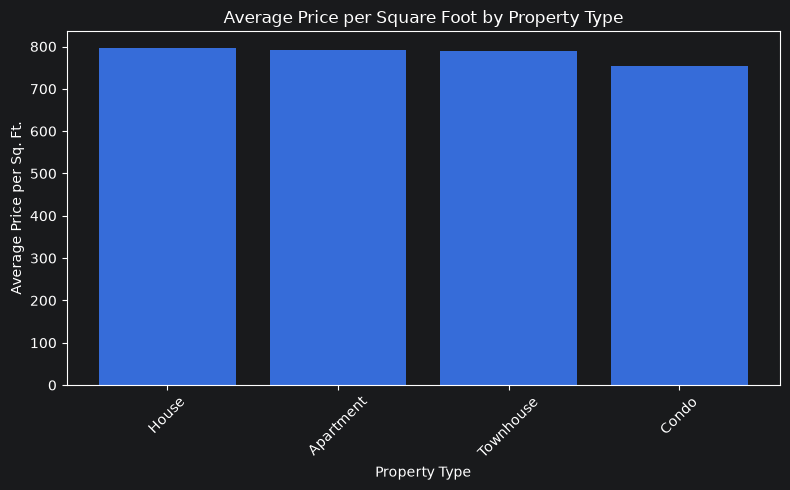

In [4]:
# Property & Pricing Analysis
#2. What is the average price per square foot by property type?


#Coding

query = """
SELECT
    property_type,
    ROUND(AVG(price / sqft), 2) AS avg_price_per_sqft
FROM listings
WHERE sqft > 0
GROUP BY property_type
ORDER BY avg_price_per_sqft DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

query = """
SELECT
    property_type,
    ROUND(AVG(price / sqft), 2) AS avg_price_per_sqft
FROM listings
WHERE sqft > 0
GROUP BY property_type
ORDER BY avg_price_per_sqft DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

price_sqft_df = pd.DataFrame(
    rows,
    columns=["Property Type", "Average Price per Sq. Ft."]
)

print(price_sqft_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(price_sqft_df["Property Type"], price_sqft_df["Average Price per Sq. Ft."])

plt.title("Average Price per Square Foot by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price per Sq. Ft.")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

('Furnished', Decimal('2463539.06'), 6977)
('Semi-Furnished', Decimal('2461192.65'), 7013)
('Unfurnished', Decimal('2433975.10'), 7210)
  Furnishing Status Average Property Price  Number of Properties
0         Furnished             2463539.06                  6977
1    Semi-Furnished             2461192.65                  7013
2       Unfurnished             2433975.10                  7210


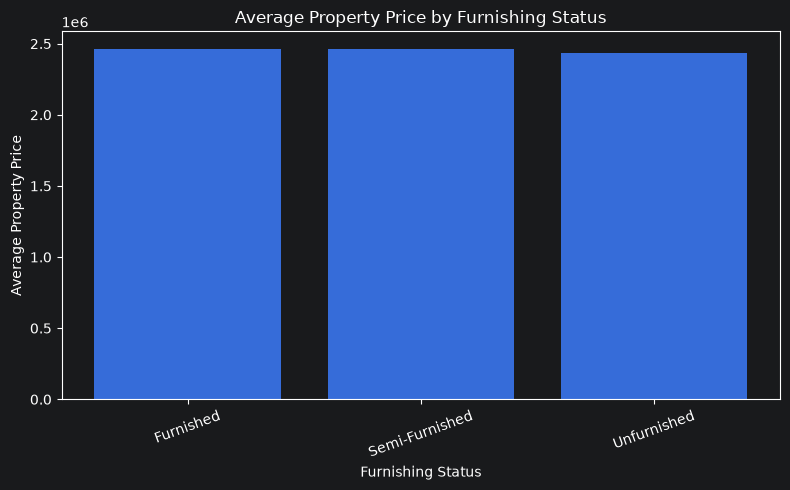

In [6]:
# Property & Pricing Analysis
#3. How does furnishing status impact property prices?


#Coding

query = """
SELECT
    pa.furnishing_status,
    ROUND(AVG(l.price), 2) AS average_property_price,
    COUNT(*) AS total_properties
FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id
GROUP BY pa.furnishing_status
ORDER BY average_property_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

query = """
SELECT
    pa.furnishing_status,
    ROUND(AVG(l.price), 2) AS average_property_price,
    COUNT(*) AS total_properties
FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id
GROUP BY pa.furnishing_status
ORDER BY average_property_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

furnishing_df = pd.DataFrame(
    rows,
    columns=[
        "Furnishing Status",
        "Average Property Price",
        "Number of Properties"
    ]
)

print(furnishing_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    furnishing_df["Furnishing Status"],
    furnishing_df["Average Property Price"]
)

plt.title("Average Property Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Property Price")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


('0-1 km', Decimal('2386849.26'), 1401)
('1-3 km', Decimal('2399214.25'), 2969)
('3-5 km', Decimal('2392399.27'), 2954)
('Above 5 km', Decimal('2483642.71'), 13876)
  Metro Distance Average Price  Number of Properties
0         0-1 km    2386849.26                  1401
1         1-3 km    2399214.25                  2969
2         3-5 km    2392399.27                  2954
3     Above 5 km    2483642.71                 13876


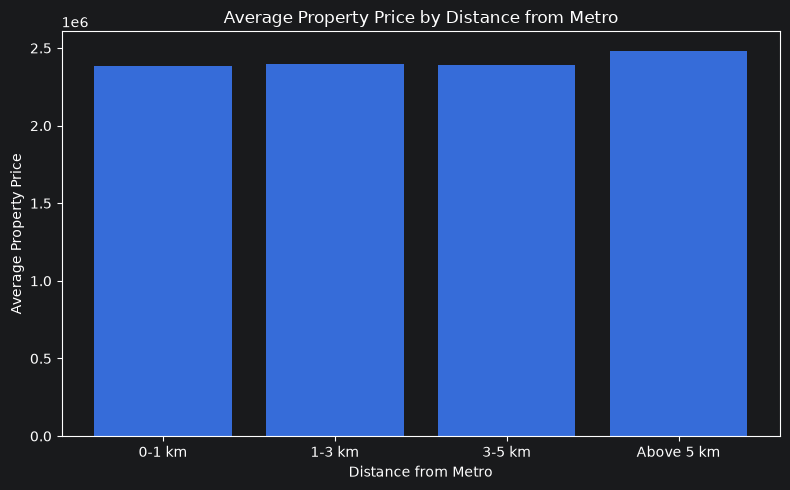

In [7]:
# Property & Pricing Analysis
#4. Do properties closer to metro stations command higher prices?


# Coding

query = """
SELECT
    CASE
        WHEN pa.metro_distance_km <= 1 THEN '0-1 km'
        WHEN pa.metro_distance_km <= 3 THEN '1-3 km'
        WHEN pa.metro_distance_km <= 5 THEN '3-5 km'
        ELSE 'Above 5 km'
    END AS metro_distance_range,

    ROUND(AVG(l.price),2) AS average_price,
    COUNT(*) AS total_properties

FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id

GROUP BY metro_distance_range

ORDER BY
CASE
    WHEN metro_distance_range='0-1 km' THEN 1
    WHEN metro_distance_range='1-3 km' THEN 2
    WHEN metro_distance_range='3-5 km' THEN 3
    ELSE 4
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

metro_df = pd.DataFrame(
    rows,
    columns=[
        "Metro Distance",
        "Average Price",
        "Number of Properties"
    ]
)

print(metro_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    metro_df["Metro Distance"],
    metro_df["Average Price"]
)

plt.title("Average Property Price by Distance from Metro")
plt.xlabel("Distance from Metro")
plt.ylabel("Average Property Price")

plt.tight_layout()
plt.show()

('Rented', Decimal('2457184.90'), 10578)
('Not Rented', Decimal('2448250.30'), 10622)
  Rental Status Average Price  Number of Properties
0        Rented    2457184.90                 10578
1    Not Rented    2448250.30                 10622


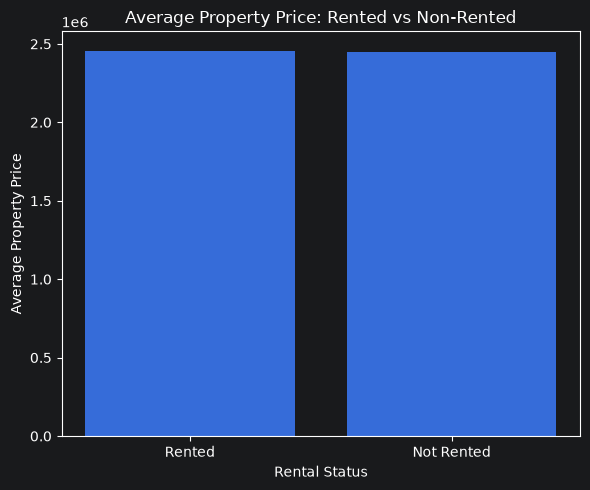

In [9]:
#Property & Pricing Analysis
#5. Are rented properties priced differently from non-rented ones?
query = """
SELECT
    CASE
        WHEN pa.is_rented = 1 THEN 'Rented'
        ELSE 'Not Rented'
    END AS rental_status,

    ROUND(AVG(l.price), 2) AS average_price,
    COUNT(*) AS total_properties

FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id

GROUP BY pa.is_rented

ORDER BY average_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

rented_df = pd.DataFrame(
    rows,
    columns=[
        "Rental Status",
        "Average Price",
        "Number of Properties"
    ]
)

print(rented_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    rented_df["Rental Status"],
    rented_df["Average Price"]
)

plt.title("Average Property Price: Rented vs Non-Rented")
plt.xlabel("Rental Status")
plt.ylabel("Average Property Price")

plt.tight_layout()
plt.show()

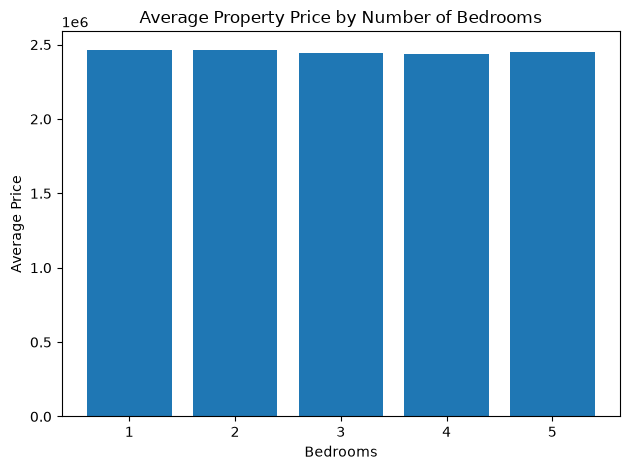

(1, 4209, Decimal('2464485.65'))
(2, 4276, Decimal('2465977.49'))
(3, 4194, Decimal('2442314.48'))
(4, 4269, Decimal('2438335.05'))
(5, 4252, Decimal('2452388.87'))
   Bedrooms  Total Properties Average Price
0         1              4209    2464485.65
1         2              4276    2465977.49
2         3              4194    2442314.48
3         4              4269    2438335.05
4         5              4252    2452388.87
(Decimal('1.0'), 5315, Decimal('2426903.06'))
(Decimal('2.0'), 5341, Decimal('2444215.70'))
(Decimal('3.0'), 5218, Decimal('2442906.54'))
(Decimal('4.0'), 5326, Decimal('2496579.88'))
  Bathrooms  Total Properties Average Price
0       1.0              5315    2426903.06
1       2.0              5341    2444215.70
2       3.0              5218    2442906.54
3       4.0              5326    2496579.88


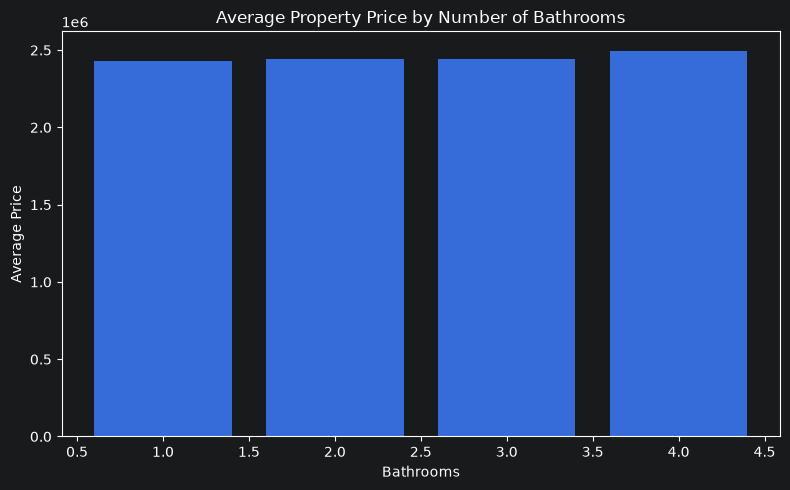

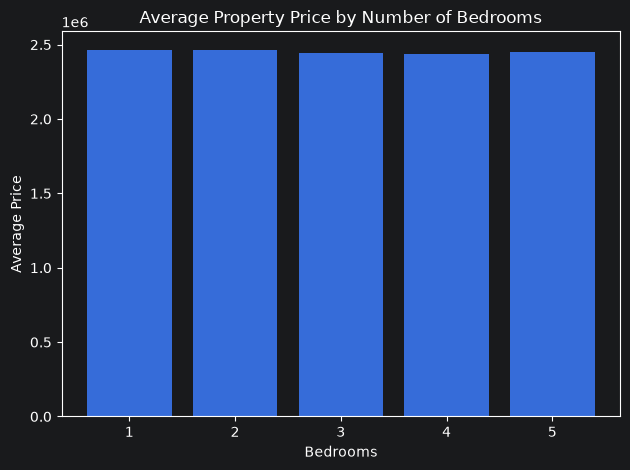

In [14]:
#Property & Pricing Analysis
#6. How do bedrooms and bathrooms affect pricing?


#Average Price by Bedrooms AND Bathrooms


#Average Price by Number of Bedrooms
query = """
SELECT
    pa.bedrooms,
    COUNT(*) AS total_properties,
    ROUND(AVG(l.price),2) AS average_price
FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id
GROUP BY pa.bedrooms
ORDER BY pa.bedrooms;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

import pandas as pd

bedroom_df = pd.DataFrame(
    rows,
    columns=[
        "Bedrooms",
        "Total Properties",
        "Average Price"
    ]
)

print(bedroom_df)


#Average Price by Number of Bathrooms
query = """
SELECT
    pa.bathrooms,
    COUNT(*) AS total_properties,
    ROUND(AVG(l.price),2) AS average_price
FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id
GROUP BY pa.bathrooms
ORDER BY pa.bathrooms;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

bathroom_df = pd.DataFrame(
    rows,
    columns=[
        "Bathrooms",
        "Total Properties",
        "Average Price"
    ]
)

print(bathroom_df)


# Visualization (Bathrooms vs Average Price)
plt.figure(figsize=(8,5))

plt.bar(
    bathroom_df["Bathrooms"],
    bathroom_df["Average Price"]
)

plt.title("Average Property Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()


#Visualization (Bedrooms vs Average Price)

import matplotlib.pyplot as plt

plt.figure

plt.bar(
    bedroom_df["Bedrooms"],
    bedroom_df["Average Price"]
)

plt.title("Average Property Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

('Parking + Power Backup', 5243, Decimal('2465651.62'))
('Parking Only', 5383, Decimal('2462363.80'))
('Power Backup Only', 5166, Decimal('2446292.59'))
('Neither Available', 5408, Decimal('2436677.75'))
                Amenities  Total Properties Average Price
0  Parking + Power Backup              5243    2465651.62
1            Parking Only              5383    2462363.80
2       Power Backup Only              5166    2446292.59
3       Neither Available              5408    2436677.75


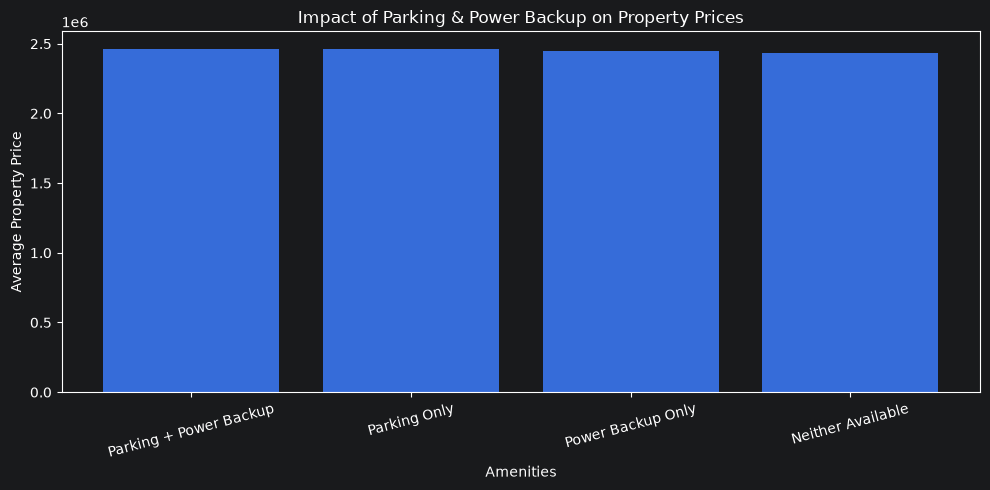

(1, 1, 5243, Decimal('2465651.62'))
(1, 0, 5383, Decimal('2462363.80'))
(0, 1, 5166, Decimal('2446292.59'))
(0, 0, 5408, Decimal('2436677.75'))


In [15]:
#Property & Pricing Analysis
#7. Do properties with parking and power backup sell at higher prices?


#Compare Average Price by Parking & Power Backup

query = """
SELECT
    CASE
        WHEN pa.parking_available = 1 AND pa.power_backup = 1 THEN 'Parking + Power Backup'
        WHEN pa.parking_available = 1 AND pa.power_backup = 0 THEN 'Parking Only'
        WHEN pa.parking_available = 0 AND pa.power_backup = 1 THEN 'Power Backup Only'
        ELSE 'Neither Available'
    END AS amenities,

    COUNT(*) AS total_properties,
    ROUND(AVG(l.price), 2) AS average_price

FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id

GROUP BY amenities

ORDER BY average_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

amenities_df = pd.DataFrame(
    rows,
    columns=[
        "Amenities",
        "Total Properties",
        "Average Price"
    ]
)

print(amenities_df)


#Visualisation

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    amenities_df["Amenities"],
    amenities_df["Average Price"]
)

plt.title("Impact of Parking & Power Backup on Property Prices")
plt.xlabel("Amenities")
plt.ylabel("Average Property Price")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


#Analyze Parking and Power Backup Separately

query = """
SELECT
    pa.parking_available,
    pa.power_backup,
    COUNT(*) AS total_properties,
    ROUND(AVG(l.price), 2) AS average_price

FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id

GROUP BY pa.parking_available, pa.power_backup

ORDER BY average_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

In [16]:
#Property & Pricing Analysis
#8. How does year built influence listing price?


#Average Listing Price by Year Built

query = """
SELECT
    pa.year_built,
    COUNT(*) AS total_properties,
    ROUND(AVG(l.price), 2) AS average_listing_price
FROM listings l
JOIN property_attributes pa
ON l.listing_id = pa.listing_id
GROUP BY pa.year_built
ORDER BY pa.year_built;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

year_price_df = pd.DataFrame(
    rows,
    columns=[
        "Year Built",
        "Total Properties",
        "Average Listing Price"
    ]
)

print(year_price_df)

(1990, 607, Decimal('2533791.60'))
(1991, 605, Decimal('2573916.58'))
(1992, 574, Decimal('2594651.56'))
(1993, 548, Decimal('2611748.25'))
(1994, 608, Decimal('2571504.92'))
(1995, 608, Decimal('2434727.72'))
(1996, 617, Decimal('2391385.75'))
(1997, 610, Decimal('2493105.20'))
(1998, 649, Decimal('2398158.87'))
(1999, 655, Decimal('2498402.48'))
(2000, 627, Decimal('2436148.36'))
(2001, 635, Decimal('2438764.29'))
(2002, 614, Decimal('2433615.48'))
(2003, 573, Decimal('2395754.95'))
(2004, 641, Decimal('2410642.66'))
(2005, 607, Decimal('2518303.24'))
(2006, 609, Decimal('2464741.47'))
(2007, 615, Decimal('2379428.80'))
(2008, 603, Decimal('2471225.25'))
(2009, 630, Decimal('2401619.13'))
(2010, 598, Decimal('2401119.97'))
(2011, 598, Decimal('2440249.43'))
(2012, 660, Decimal('2302495.50'))
(2013, 625, Decimal('2348081.45'))
(2014, 646, Decimal('2358476.99'))
(2015, 649, Decimal('2457272.07'))
(2016, 650, Decimal('2428168.81'))
(2017, 602, Decimal('2393633.46'))
(2018, 668, Decimal(

In [18]:
#Property & Pricing Analysis
#9. Which cities have the highest average property prices?
query = """
SELECT
    city,
    COUNT(*) AS total_properties,
    ROUND(AVG(price), 2) AS average_property_price
FROM listings
GROUP BY city
ORDER BY average_property_price DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


import pandas as pd

city_price_df = pd.DataFrame(
    rows,
    columns=[
        "City",
        "Total Properties",
        "Average Property Price"
    ]
)

print(city_price_df)

('New York', 4269, Decimal('2493319.74'))
('Phoenix', 4229, Decimal('2459961.76'))
('Los Angeles', 4318, Decimal('2442418.31'))
('Houston', 4091, Decimal('2436811.00'))
('Chicago', 4293, Decimal('2430677.90'))
          City  Total Properties Average Property Price
0     New York              4269             2493319.74
1      Phoenix              4229             2459961.76
2  Los Angeles              4318             2442418.31
3      Houston              4091             2436811.00
4      Chicago              4293             2430677.90


('Below 500K', 1867, Decimal('302820.56'))
('500K - 999K', 2402, Decimal('748046.56'))
('1M - 1.49M', 2393, Decimal('1251193.86'))
('1.5M - 1.99M', 2407, Decimal('1747033.95'))
('2M and Above', 12131, Decimal('3498147.32'))
   Price Bucket  Total Properties Average Price
0    Below 500K              1867     302820.56
1   500K - 999K              2402     748046.56
2    1M - 1.49M              2393    1251193.86
3  1.5M - 1.99M              2407    1747033.95
4  2M and Above             12131    3498147.32


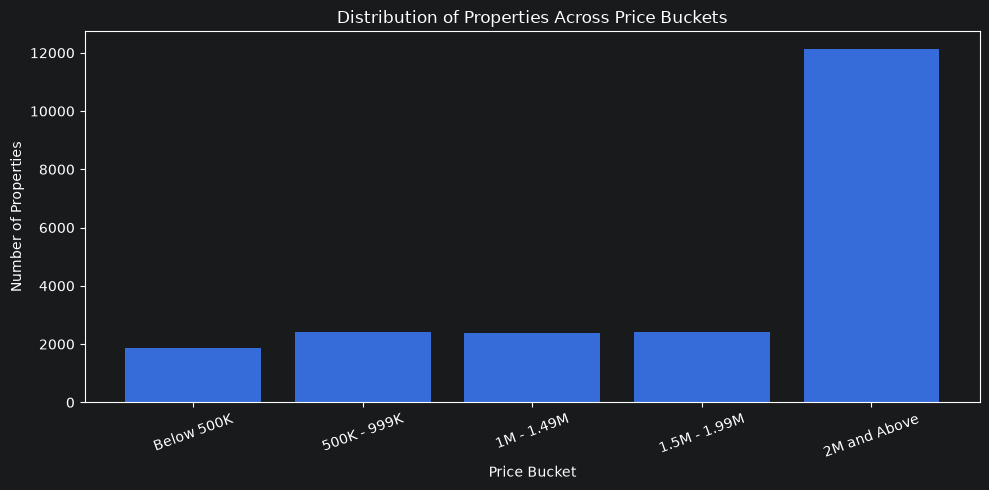

In [19]:
#Property & Pricing Analysis
#10. How are properties distributed across price buckets?


#Coding

query = """
SELECT
    CASE
        WHEN price < 500000 THEN 'Below 500K'
        WHEN price BETWEEN 500000 AND 999999 THEN '500K - 999K'
        WHEN price BETWEEN 1000000 AND 1499999 THEN '1M - 1.49M'
        WHEN price BETWEEN 1500000 AND 1999999 THEN '1.5M - 1.99M'
        ELSE '2M and Above'
    END AS price_bucket,

    COUNT(*) AS total_properties,
    ROUND(AVG(price), 2) AS average_price

FROM listings

GROUP BY price_bucket

ORDER BY
CASE
    WHEN price_bucket = 'Below 500K' THEN 1
    WHEN price_bucket = '500K - 999K' THEN 2
    WHEN price_bucket = '1M - 1.49M' THEN 3
    WHEN price_bucket = '1.5M - 1.99M' THEN 4
    ELSE 5
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

price_bucket_df = pd.DataFrame(
    rows,
    columns=[
        "Price Bucket",
        "Total Properties",
        "Average Price"
    ]
)

print(price_bucket_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    price_bucket_df["Price Bucket"],
    price_bucket_df["Total Properties"]
)

plt.title("Distribution of Properties Across Price Buckets")
plt.xlabel("Price Bucket")
plt.ylabel("Number of Properties")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

('Los Angeles', 128, Decimal('65.13'), 5, 119)
('Chicago', 156, Decimal('64.25'), 5, 120)
('New York', 137, Decimal('60.85'), 5, 119)
('Phoenix', 168, Decimal('59.65'), 5, 120)
('Houston', 131, Decimal('58.51'), 5, 120)
          City  Properties Sold Average Days on Market  \
0  Los Angeles              128                  65.13   
1      Chicago              156                  64.25   
2     New York              137                  60.85   
3      Phoenix              168                  59.65   
4      Houston              131                  58.51   

   Minimum Days on Market  Maximum Days on Market  
0                       5                     119  
1                       5                     120  
2                       5                     119  
3                       5                     120  
4                       5                     120  


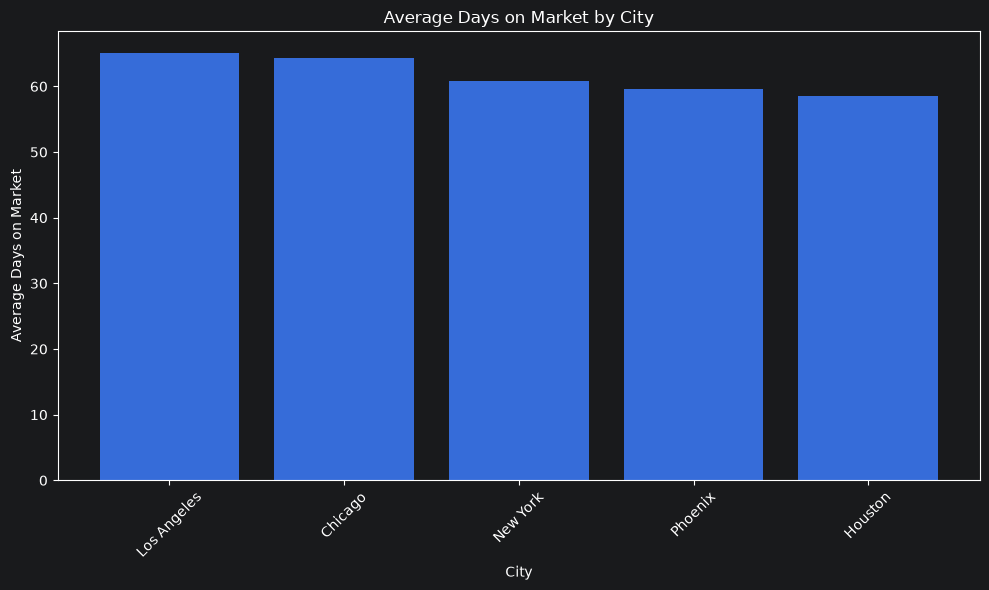

In [20]:
#Sales & Market Performance
#11. What is the average days on market by city?
query = """
SELECT
    l.city,
    COUNT(*) AS total_properties_sold,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_on_market,
    MIN(s.days_on_market) AS min_days_on_market,
    MAX(s.days_on_market) AS max_days_on_market
FROM listings l
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY l.city
ORDER BY avg_days_on_market DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

market_df = pd.DataFrame(
    rows,
    columns=[
        "City",
        "Properties Sold",
        "Average Days on Market",
        "Minimum Days on Market",
        "Maximum Days on Market"
    ]
)

print(market_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    market_df["City"],
    market_df["Average Days on Market"],
)

plt.title("Average Days on Market by City")
plt.xlabel("City")
plt.ylabel("Average Days on Market")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


('House', 190, Decimal('58.34'), 5, 119)
('Apartment', 176, Decimal('60.65'), 5, 120)
('Townhouse', 167, Decimal('60.96'), 5, 120)
('Condo', 187, Decimal('66.54'), 5, 120)
  Property Type  Properties Sold Average Days on Market  Fastest Sale (Days)  \
0         House              190                  58.34                    5   
1     Apartment              176                  60.65                    5   
2     Townhouse              167                  60.96                    5   
3         Condo              187                  66.54                    5   

   Slowest Sale (Days)  
0                  119  
1                  120  
2                  120  
3                  120  


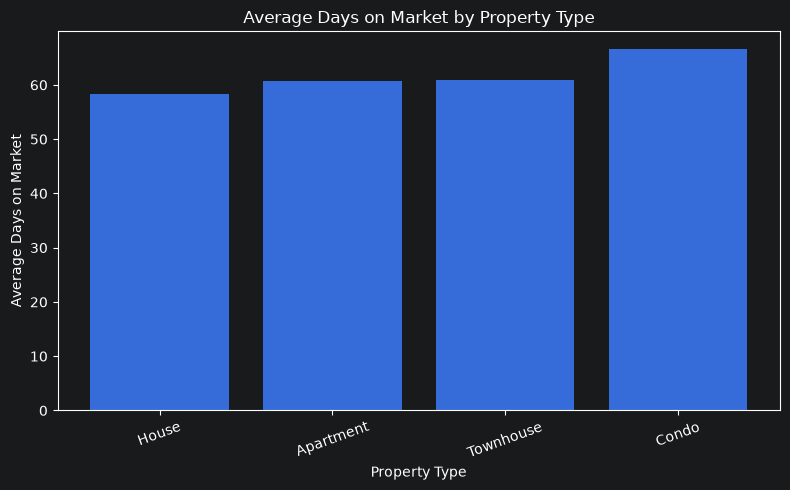

In [22]:
#property & Pricing analysis
#12. Which property types sell the fastest?
query = """
SELECT
    l.property_type,
    COUNT(*) AS total_properties_sold,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_on_market,
    MIN(s.days_on_market) AS fastest_sale,
    MAX(s.days_on_market) AS slowest_sale
FROM listings l
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY l.property_type
ORDER BY avg_days_on_market ASC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display

import pandas as pd

property_sales_df = pd.DataFrame(
    rows,
    columns=[
        "Property Type",
        "Properties Sold",
        "Average Days on Market",
        "Fastest Sale (Days)",
        "Slowest Sale (Days)"
    ]
)

print(property_sales_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    property_sales_df["Property Type"],
    property_sales_df["Average Days on Market"]
)

plt.title("Average Days on Market by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Days on Market")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

(720, Decimal('355'), Decimal('0'), Decimal('365'), Decimal('49.31'))
   Total Properties Sold Sold Above Listing Sold At Listing  \
0                    720                355               0   

  Sold Below Listing Percentage Above Listing (%)  
0                365                        49.31  


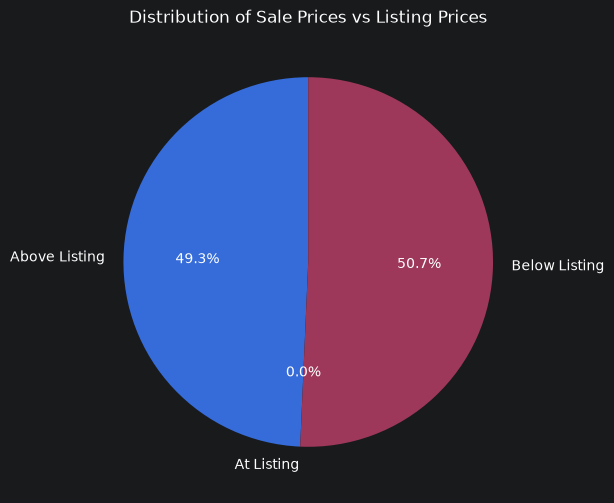

In [23]:
#Sales & Market Performance
#13 What percentage of properties are sold above listing price?


#coding

query = """
SELECT
    COUNT(*) AS total_properties_sold,

    SUM(CASE
            WHEN s.sale_price > l.price THEN 1
            ELSE 0
        END) AS sold_above_listing,

    SUM(CASE
            WHEN s.sale_price = l.price THEN 1
            ELSE 0
        END) AS sold_at_listing,

    SUM(CASE
            WHEN s.sale_price < l.price THEN 1
            ELSE 0
        END) AS sold_below_listing,

    ROUND(
        (SUM(CASE
                WHEN s.sale_price > l.price THEN 1
                ELSE 0
            END) * 100.0) / COUNT(*),
        2
    ) AS percentage_above_listing

FROM listings l
JOIN sales s
ON l.listing_id = s.listing_id;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display as a DataFrame

import pandas as pd

sales_summary_df = pd.DataFrame(
    rows,
    columns=[
        "Total Properties Sold",
        "Sold Above Listing",
        "Sold At Listing",
        "Sold Below Listing",
        "Percentage Above Listing (%)"
    ]
)

print(sales_summary_df)


#Visualize the Distribution

import matplotlib.pyplot as plt

labels = [
    "Above Listing",
    "At Listing",
    "Below Listing"
]

sizes = sales_summary_df.loc[
    0,
    ["Sold Above Listing", "Sold At Listing", "Sold Below Listing"]
].astype(float).tolist()

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Sale Prices vs Listing Prices")

plt.show()

('Chicago', 156, Decimal('1084682.31'), Decimal('1085111.03'), Decimal('100.15'))
('Houston', 131, Decimal('1170492.05'), Decimal('1170807.64'), Decimal('100.00'))
('Los Angeles', 128, Decimal('1056283.01'), Decimal('1054262.44'), Decimal('99.98'))
('New York', 137, Decimal('1065338.55'), Decimal('1063331.14'), Decimal('99.96'))
('Phoenix', 168, Decimal('1028713.16'), Decimal('1027130.83'), Decimal('99.89'))
          City  Properties Sold Average Listing Price Average Sale Price  \
0      Chicago              156            1084682.31         1085111.03   
1      Houston              131            1170492.05         1170807.64   
2  Los Angeles              128            1056283.01         1054262.44   
3     New York              137            1065338.55         1063331.14   
4      Phoenix              168            1028713.16         1027130.83   

  Sale-to-List Ratio (%)  
0                 100.15  
1                 100.00  
2                  99.98  
3                  99.9

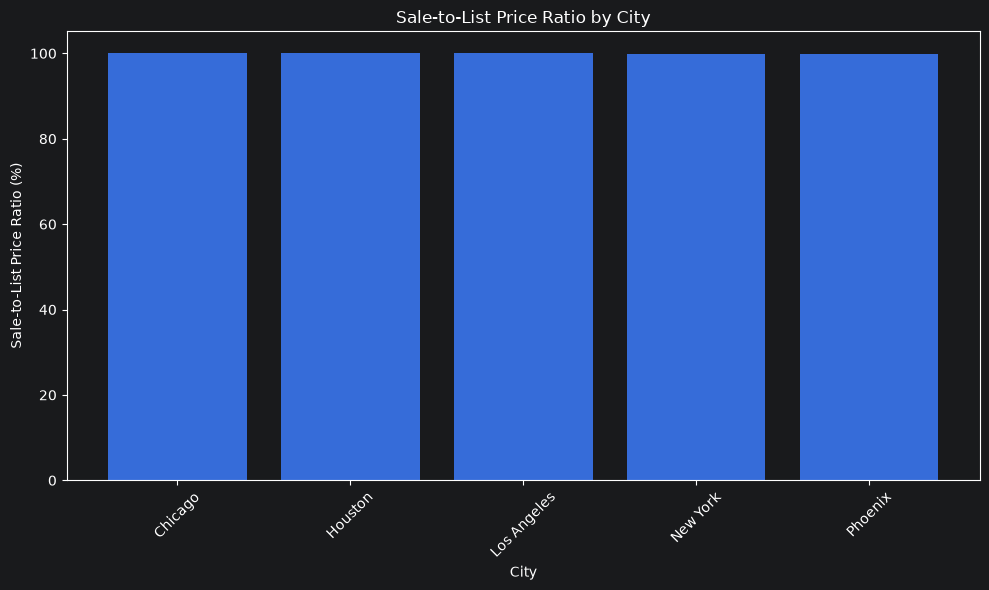

In [24]:
#Sales & Market Performance
#14. What is the sale-to-list price ratio by city?
#coding
query = """
SELECT
    l.city,
    COUNT(*) AS total_properties_sold,
    ROUND(AVG(l.price), 2) AS avg_listing_price,
    ROUND(AVG(s.sale_price), 2) AS avg_sale_price,
    ROUND(AVG((s.sale_price / l.price) * 100), 2) AS sale_to_list_ratio
FROM listings l
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY l.city
ORDER BY sale_to_list_ratio DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame
import pandas as pd

ratio_df = pd.DataFrame(
    rows,
    columns=[
        "City",
        "Properties Sold",
        "Average Listing Price",
        "Average Sale Price",
        "Sale-to-List Ratio (%)"
    ]
)

print(ratio_df)

#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    ratio_df["City"],
    ratio_df["Sale-to-List Ratio (%)"]
)

plt.title("Sale-to-List Price Ratio by City")
plt.xlabel("City")
plt.ylabel("Sale-to-List Price Ratio (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
#Sales & Market Performance
#15. Which listings took more than 90 days to sell?


#coding

query = """
SELECT
    l.listing_id,
    l.city,
    l.property_type,
    ROUND(l.price, 2) AS listing_price,
    ROUND(s.sale_price, 2) AS sale_price,
    s.days_on_market,
    s.date_sold
FROM listings l
JOIN sales s
ON l.listing_id = s.listing_id
WHERE s.days_on_market > 90
ORDER BY s.days_on_market DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

slow_sales_df = pd.DataFrame(
    rows,
    columns=[
        "Listing ID",
        "City",
        "Property Type",
        "Listing Price",
        "Sale Price",
        "Days on Market",
        "Date Sold"
    ]
)

print(slow_sales_df)

('L00067', 'Chicago', 'Apartment', Decimal('293562.99'), Decimal('286681.00'), 120, datetime.date(2024, 6, 28))
('L00157', 'Phoenix', 'Townhouse', Decimal('710815.00'), Decimal('707140.98'), 120, datetime.date(2023, 8, 27))
('L00179', 'Chicago', 'Condo', Decimal('971345.99'), Decimal('1017871.01'), 120, datetime.date(2023, 12, 28))
('L00259', 'Phoenix', 'Apartment', Decimal('1513413.99'), Decimal('1577127.00'), 120, datetime.date(2023, 9, 17))
('L00287', 'Houston', 'Townhouse', Decimal('1724170.00'), Decimal('1769308.00'), 120, datetime.date(2024, 4, 12))
('L00057', 'Phoenix', 'Condo', Decimal('646864.99'), Decimal('665657.00'), 119, datetime.date(2024, 4, 6))
('L00078', 'Los Angeles', 'House', Decimal('149627.00'), Decimal('152524.01'), 119, datetime.date(2023, 11, 20))
('L00271', 'New York', 'House', Decimal('1013679.01'), Decimal('970384.01'), 119, datetime.date(2024, 1, 23))
('L00348', 'New York', 'Condo', Decimal('1969257.99'), Decimal('2031708.00'), 119, datetime.date(2024, 7, 8)

('0-1 km', 69, Decimal('64.52'), 5, 119)
('1-3 km', 163, Decimal('64.28'), 5, 120)
('3-5 km', 188, Decimal('59.85'), 5, 119)
('Above 5 km', 300, Decimal('60.67'), 5, 120)
  Metro Distance  Total Properties Average Days on Market  Minimum Days  \
0         0-1 km                69                  64.52             5   
1         1-3 km               163                  64.28             5   
2         3-5 km               188                  59.85             5   
3     Above 5 km               300                  60.67             5   

   Maximum Days  
0           119  
1           120  
2           119  
3           120  


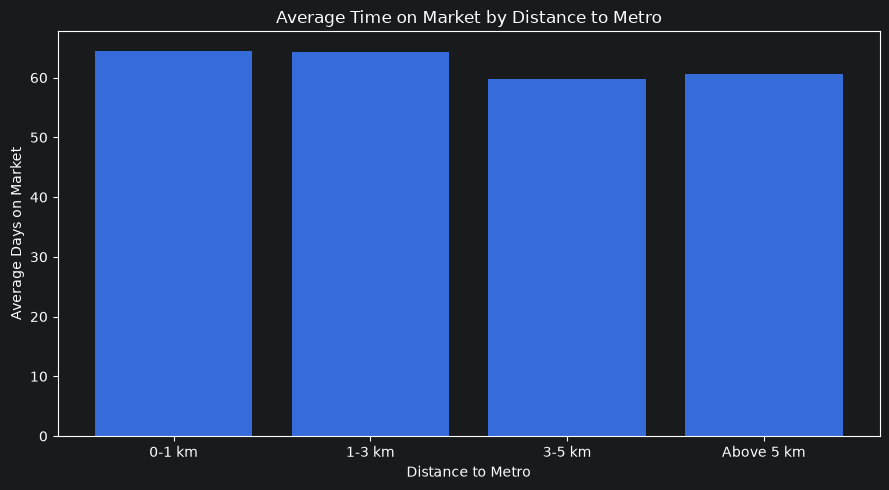

In [26]:
#Sales & Market Performance
#16.How does metro distance affect time on market?


#coding

query = """
SELECT
    CASE
        WHEN pa.metro_distance_km <= 1 THEN '0-1 km'
        WHEN pa.metro_distance_km <= 3 THEN '1-3 km'
        WHEN pa.metro_distance_km <= 5 THEN '3-5 km'
        ELSE 'Above 5 km'
    END AS metro_distance,

    COUNT(*) AS total_properties,

    ROUND(AVG(s.days_on_market),2) AS avg_days_on_market,

    MIN(s.days_on_market) AS minimum_days,

    MAX(s.days_on_market) AS maximum_days

FROM property_attributes pa
JOIN sales s
ON pa.listing_id = s.listing_id

GROUP BY metro_distance

ORDER BY
CASE
    WHEN metro_distance = '0-1 km' THEN 1
    WHEN metro_distance = '1-3 km' THEN 2
    WHEN metro_distance = '3-5 km' THEN 3
    ELSE 4
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

metro_market_df = pd.DataFrame(
    rows,
    columns=[
        "Metro Distance",
        "Total Properties",
        "Average Days on Market",
        "Minimum Days",
        "Maximum Days"
    ]
)

print(metro_market_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.bar(
    metro_market_df["Metro Distance"],
    metro_market_df["Average Days on Market"]
)

plt.title("Average Time on Market by Distance to Metro")
plt.xlabel("Distance to Metro")
plt.ylabel("Average Days on Market")

plt.tight_layout()
plt.show()

('2023-01', 7)
('2023-02', 17)
('2023-03', 20)
('2023-04', 36)
('2023-05', 45)
('2023-06', 31)
('2023-07', 48)
('2023-08', 50)
('2023-09', 46)
('2023-10', 64)
('2023-11', 46)
('2023-12', 42)
('2024-01', 44)
('2024-02', 44)
('2024-03', 39)
('2024-04', 29)
('2024-05', 45)
('2024-06', 29)
('2024-07', 24)
('2024-08', 13)
('2024-09', 1)
   Sales Month  Properties Sold
0      2023-01                7
1      2023-02               17
2      2023-03               20
3      2023-04               36
4      2023-05               45
5      2023-06               31
6      2023-07               48
7      2023-08               50
8      2023-09               46
9      2023-10               64
10     2023-11               46
11     2023-12               42
12     2024-01               44
13     2024-02               44
14     2024-03               39
15     2024-04               29
16     2024-05               45
17     2024-06               29
18     2024-07               24
19     2024-08            

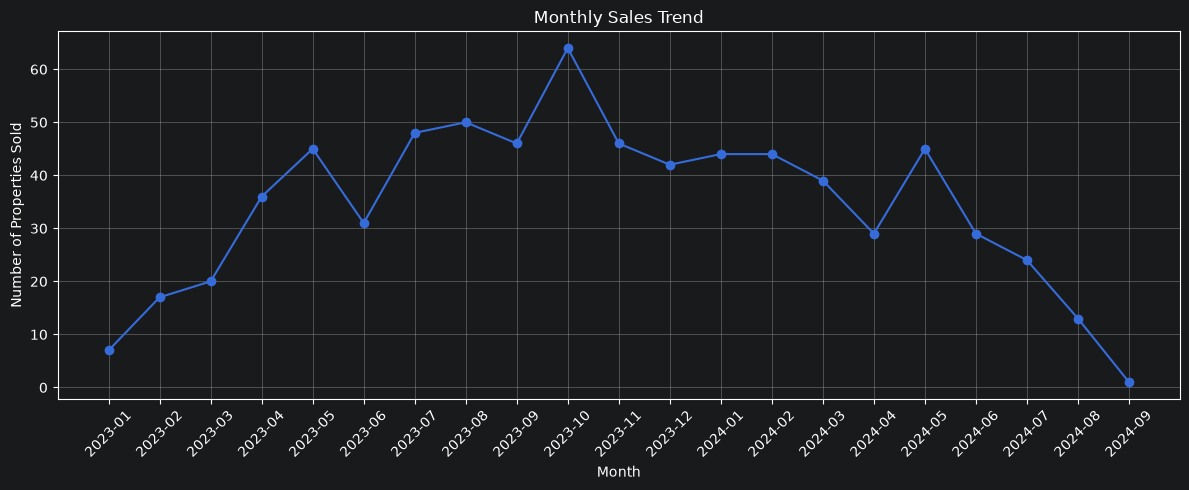

In [27]:
#Sales & Market Performance
#17. What is the monthly sales trend?


#coding

query = """
SELECT
    DATE_FORMAT(date_sold, '%Y-%m') AS sales_month,
    COUNT(*) AS total_properties_sold
FROM sales
GROUP BY DATE_FORMAT(date_sold, '%Y-%m')
ORDER BY sales_month;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

monthly_sales_df = pd.DataFrame(
    rows,
    columns=[
        "Sales Month",
        "Properties Sold"
    ]
)

print(monthly_sales_df)


#Visualization- Line Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales_df["Sales Month"],
    monthly_sales_df["Properties Sold"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Properties Sold")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

('L18958', 'Phoenix', 'House', Decimal('2313372.72'), Decimal('642.62'), datetime.date(2024, 12, 31), 'A0036')
('L21163', 'New York', 'Apartment', Decimal('3456128.72'), Decimal('5689.51'), datetime.date(2024, 12, 31), 'A0025')
('L11432', 'New York', 'Apartment', Decimal('349971.95'), Decimal('1470.88'), datetime.date(2024, 12, 31), 'A0005')
('L12297', 'Houston', 'Townhouse', Decimal('4388273.95'), Decimal('9931.44'), datetime.date(2024, 12, 31), 'A0037')
('L12840', 'Houston', 'Condo', Decimal('4244005.09'), Decimal('5062.73'), datetime.date(2024, 12, 31), 'A0046')
('L14306', 'Los Angeles', 'House', Decimal('2088858.25'), Decimal('863.31'), datetime.date(2024, 12, 31), 'A0017')
('L14735', 'Phoenix', 'House', Decimal('2653174.25'), Decimal('5155.66'), datetime.date(2024, 12, 31), 'A0001')
('L14966', 'Los Angeles', 'House', Decimal('3236122.74'), Decimal('2328.43'), datetime.date(2024, 12, 31), 'A0019')
('L01695', 'Chicago', 'Townhouse', Decimal('4645985.64'), Decimal('6471.65'), datetim

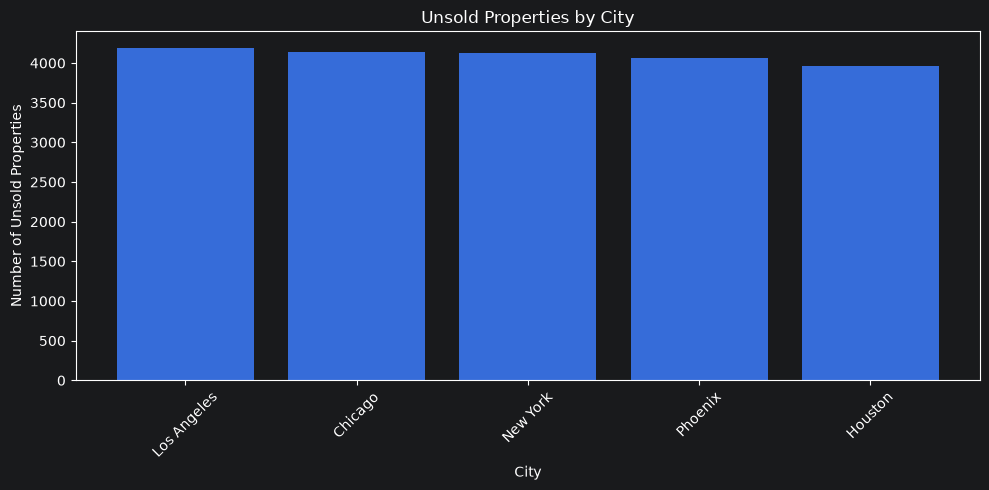

In [28]:
#Sales & Market Performance
#18. Which properties are currently unsold?


#coding

query = """
SELECT
    l.listing_id,
    l.city,
    l.property_type,
    l.price,
    l.sqft,
    l.listed_date,
    l.agent_id
FROM listings l
LEFT JOIN sales s
ON l.listing_id = s.listing_id
WHERE s.listing_id IS NULL
ORDER BY l.listed_date DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

unsold_df = pd.DataFrame(
    rows,
    columns=[
        "Listing ID",
        "City",
        "Property Type",
        "Listing Price",
        "Area (Sq. Ft.)",
        "Listed Date",
        "Agent ID"
    ]
)

print(unsold_df)


#Count the Number of Unsold Properties

query = """
SELECT COUNT(*) AS total_unsold_properties
FROM listings l
LEFT JOIN sales s
ON l.listing_id = s.listing_id
WHERE s.listing_id IS NULL;
"""

cursor.execute(query)

result = cursor.fetchone()

print("Total Unsold Properties:", result[0])


#Visualize Unsold Properties by City

query = """
SELECT
    l.city,
    COUNT(*) AS unsold_properties
FROM listings l
LEFT JOIN sales s
ON l.listing_id = s.listing_id
WHERE s.listing_id IS NULL
GROUP BY l.city
ORDER BY unsold_properties DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

city_unsold_df = pd.DataFrame(
    rows,
    columns=[
        "City",
        "Unsold Properties"
    ]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    city_unsold_df["City"],
    city_unsold_df["Unsold Properties"]
)

plt.title("Unsold Properties by City")
plt.xlabel("City")
plt.ylabel("Number of Unsold Properties")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


('A0042', 'Agent A0042', 25, Decimal('27191605.99'), Decimal('1087664.24'))
('A0011', 'Agent A0011', 24, Decimal('27882272.01'), Decimal('1161761.33'))
('A0014', 'Agent A0014', 21, Decimal('22034008.02'), Decimal('1049238.48'))
('A0035', 'Agent A0035', 21, Decimal('22725751.98'), Decimal('1082178.67'))
('A0043', 'Agent A0043', 20, Decimal('24102418.01'), Decimal('1205120.90'))
('A0046', 'Agent A0046', 20, Decimal('21335804.97'), Decimal('1066790.25'))
('A0007', 'Agent A0007', 19, Decimal('18414480.01'), Decimal('969183.16'))
('A0048', 'Agent A0048', 19, Decimal('21186305.99'), Decimal('1115068.74'))
('A0029', 'Agent A0029', 18, Decimal('19586498.01'), Decimal('1088138.78'))
('A0027', 'Agent A0027', 18, Decimal('21099696.97'), Decimal('1172205.39'))
('A0019', 'Agent A0019', 17, Decimal('16730611.95'), Decimal('984153.64'))
('A0025', 'Agent A0025', 17, Decimal('18818591.07'), Decimal('1106975.95'))
('A0009', 'Agent A0009', 17, Decimal('20279274.94'), Decimal('1192898.53'))
('A0021', 'Age

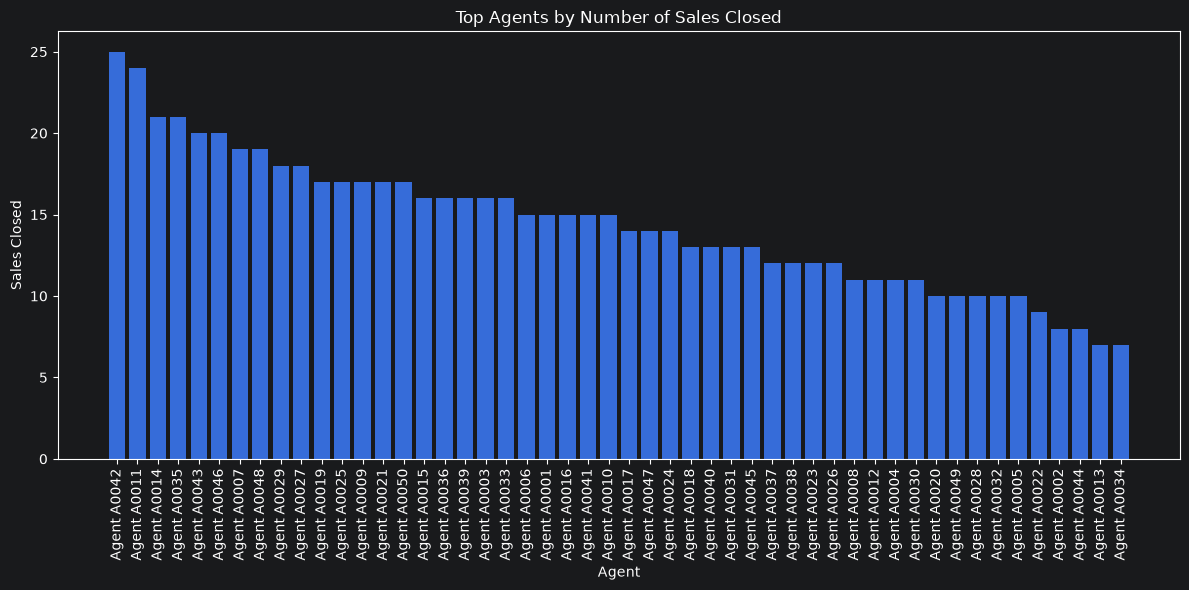

In [29]:
#Agent Performance
#19. Which agents have closed the most sales?

#coding

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(s.listing_id) AS total_sales_closed,
    ROUND(SUM(s.sale_price), 2) AS total_sales_value,
    ROUND(AVG(s.sale_price), 2) AS average_sale_price
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY a.agent_id, a.name
ORDER BY total_sales_closed DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

agent_sales_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Total Sales Closed",
        "Total Sales Value",
        "Average Sale Price"
    ]
)

print(agent_sales_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    agent_sales_df["Agent Name"],
    agent_sales_df["Total Sales Closed"]
)

plt.title("Top Agents by Number of Sales Closed")
plt.xlabel("Agent")
plt.ylabel("Sales Closed")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

('A0011', 'Agent A0011', 24, Decimal('27882272.01'), Decimal('1161761.33'))
('A0042', 'Agent A0042', 25, Decimal('27191605.99'), Decimal('1087664.24'))
('A0043', 'Agent A0043', 20, Decimal('24102418.01'), Decimal('1205120.90'))
('A0035', 'Agent A0035', 21, Decimal('22725751.98'), Decimal('1082178.67'))
('A0014', 'Agent A0014', 21, Decimal('22034008.02'), Decimal('1049238.48'))
('A0046', 'Agent A0046', 20, Decimal('21335804.97'), Decimal('1066790.25'))
('A0048', 'Agent A0048', 19, Decimal('21186305.99'), Decimal('1115068.74'))
('A0027', 'Agent A0027', 18, Decimal('21099696.97'), Decimal('1172205.39'))
('A0009', 'Agent A0009', 17, Decimal('20279274.94'), Decimal('1192898.53'))
('A0029', 'Agent A0029', 18, Decimal('19586498.01'), Decimal('1088138.78'))
('A0039', 'Agent A0039', 16, Decimal('19223013.99'), Decimal('1201438.37'))
('A0036', 'Agent A0036', 16, Decimal('19209543.94'), Decimal('1200596.50'))
('A0050', 'Agent A0050', 17, Decimal('18968547.99'), Decimal('1115796.94'))
('A0025', 'A

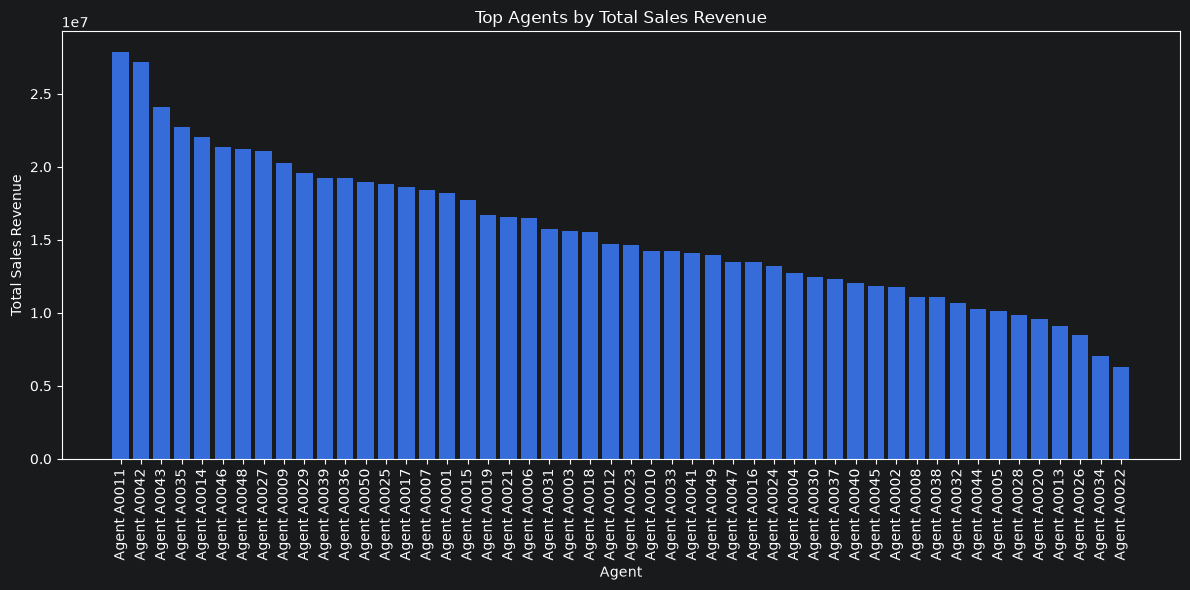

In [30]:
#Agent Performance
#20. Who are the top agents by total sales revenue?

#coding

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(s.listing_id) AS total_properties_sold,
    ROUND(SUM(s.sale_price), 2) AS total_sales_revenue,
    ROUND(AVG(s.sale_price), 2) AS average_sale_price
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY a.agent_id, a.name
ORDER BY total_sales_revenue DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

agent_revenue_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Properties Sold",
        "Total Sales Revenue",
        "Average Sale Price"
    ]
)

print(agent_revenue_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    agent_revenue_df["Agent Name"],
    agent_revenue_df["Total Sales Revenue"]
)

plt.title("Top Agents by Total Sales Revenue")
plt.xlabel("Agent")
plt.ylabel("Total Sales Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

('A0044', 'Agent A0044', 8, Decimal('36.88'), 7, 67)
('A0013', 'Agent A0013', 7, Decimal('42.43'), 9, 89)
('A0037', 'Agent A0037', 12, Decimal('44.50'), 14, 106)
('A0002', 'Agent A0002', 8, Decimal('45.50'), 9, 80)
('A0008', 'Agent A0008', 11, Decimal('46.64'), 8, 102)
('A0017', 'Agent A0017', 14, Decimal('48.57'), 5, 103)
('A0026', 'Agent A0026', 12, Decimal('49.50'), 5, 116)
('A0012', 'Agent A0012', 11, Decimal('50.64'), 6, 111)
('A0010', 'Agent A0010', 15, Decimal('51.13'), 5, 119)
('A0043', 'Agent A0043', 20, Decimal('52.35'), 13, 109)
('A0009', 'Agent A0009', 17, Decimal('52.71'), 7, 119)
('A0018', 'Agent A0018', 13, Decimal('54.69'), 8, 120)
('A0022', 'Agent A0022', 9, Decimal('55.56'), 6, 119)
('A0028', 'Agent A0028', 10, Decimal('55.60'), 15, 103)
('A0040', 'Agent A0040', 13, Decimal('55.92'), 5, 108)
('A0041', 'Agent A0041', 15, Decimal('56.13'), 5, 107)
('A0036', 'Agent A0036', 16, Decimal('56.38'), 6, 112)
('A0023', 'Agent A0023', 12, Decimal('56.50'), 5, 115)
('A0046', 'Age

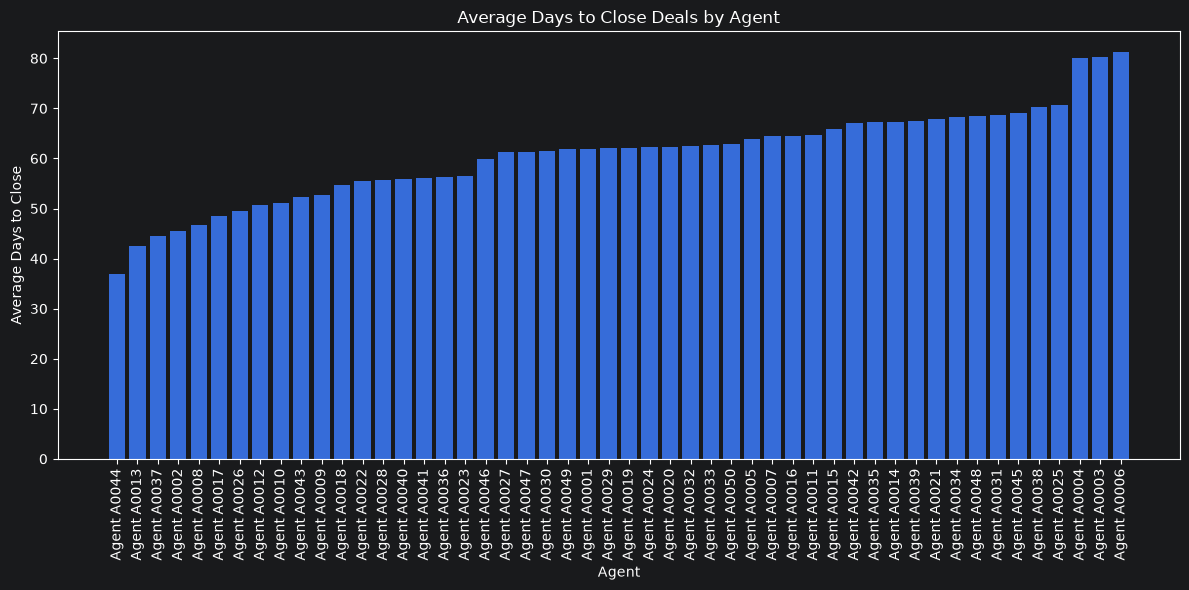

('A0044', 'Agent A0044', 8, Decimal('36.88'))
('A0013', 'Agent A0013', 7, Decimal('42.43'))
('A0037', 'Agent A0037', 12, Decimal('44.50'))
('A0002', 'Agent A0002', 8, Decimal('45.50'))
('A0008', 'Agent A0008', 11, Decimal('46.64'))
('A0017', 'Agent A0017', 14, Decimal('48.57'))
('A0026', 'Agent A0026', 12, Decimal('49.50'))
('A0012', 'Agent A0012', 11, Decimal('50.64'))
('A0010', 'Agent A0010', 15, Decimal('51.13'))
('A0043', 'Agent A0043', 20, Decimal('52.35'))


In [31]:
#Agent Performance
#21. Which agents close deals fastest?

#coding

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(s.listing_id) AS total_sales_closed,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_to_close,
    MIN(s.days_on_market) AS fastest_sale_days,
    MAX(s.days_on_market) AS slowest_sale_days
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY a.agent_id, a.name
ORDER BY avg_days_to_close ASC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

agent_speed_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Sales Closed",
        "Average Days to Close",
        "Fastest Sale (Days)",
        "Slowest Sale (Days)"
    ]
)

print(agent_speed_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    agent_speed_df["Agent Name"],
    agent_speed_df["Average Days to Close"]
)

plt.title("Average Days to Close Deals by Agent")
plt.xlabel("Agent")
plt.ylabel("Average Days to Close")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


#Top 10 Fastest Agents

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(s.listing_id) AS total_sales_closed,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_to_close
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY a.agent_id, a.name
ORDER BY avg_days_to_close ASC
LIMIT 10;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

('A0035', 'Agent A0035', 1, 262)
('A0015', 'Agent A0015', 2, 50)
('A0033', 'Agent A0033', 3, 14)
('A0007', 'Agent A0007', 4, 127)
('A0040', 'Agent A0040', 4, 153)
('A0027', 'Agent A0027', 5, 157)
('A0004', 'Agent A0004', 5, 31)
('A0041', 'Agent A0041', 5, 77)
('A0006', 'Agent A0006', 7, 63)
('A0034', 'Agent A0034', 7, 83)
('A0024', 'Agent A0024', 9, 283)
('A0046', 'Agent A0046', 10, 135)
('A0001', 'Agent A0001', 10, 52)
('A0050', 'Agent A0050', 11, 109)
('A0038', 'Agent A0038', 12, 257)
('A0042', 'Agent A0042', 13, 231)
('A0030', 'Agent A0030', 13, 296)
('A0022', 'Agent A0022', 13, 56)
('A0013', 'Agent A0013', 14, 11)
('A0025', 'Agent A0025', 14, 188)
('A0049', 'Agent A0049', 14, 17)
('A0037', 'Agent A0037', 15, 16)
('A0016', 'Agent A0016', 15, 230)
('A0005', 'Agent A0005', 16, 198)
('A0012', 'Agent A0012', 16, 24)
('A0029', 'Agent A0029', 16, 65)
('A0047', 'Agent A0047', 16, 91)
('A0010', 'Agent A0010', 17, 292)
('A0026', 'Agent A0026', 17, 225)
('A0023', 'Agent A0023', 18, 30)
('A000

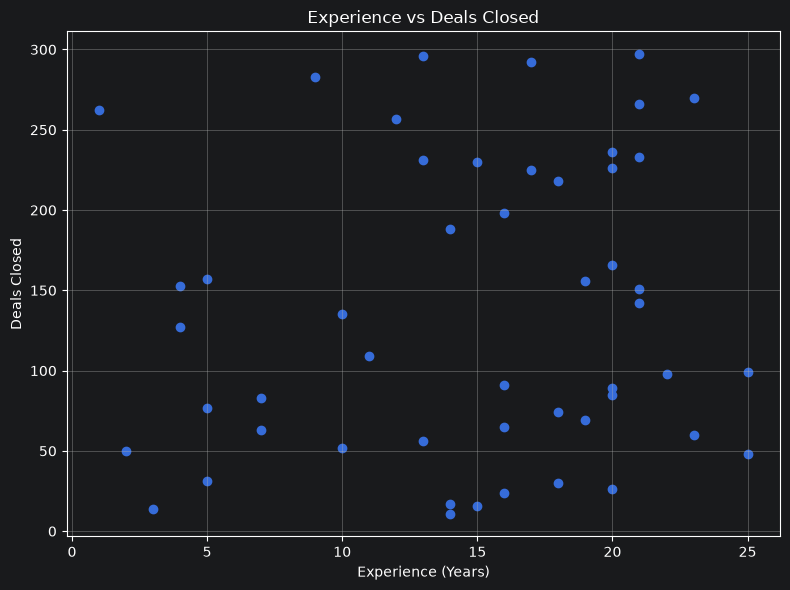

('0-2 Years', 2, Decimal('156.00'))
('3-5 Years', 6, Decimal('93.17'))
('6-10 Years', 5, Decimal('123.20'))
('10+ Years', 37, Decimal('144.46'))
  Experience Group  Total Agents Average Deals Closed
0        0-2 Years             2               156.00
1        3-5 Years             6                93.17
2       6-10 Years             5               123.20
3        10+ Years            37               144.46


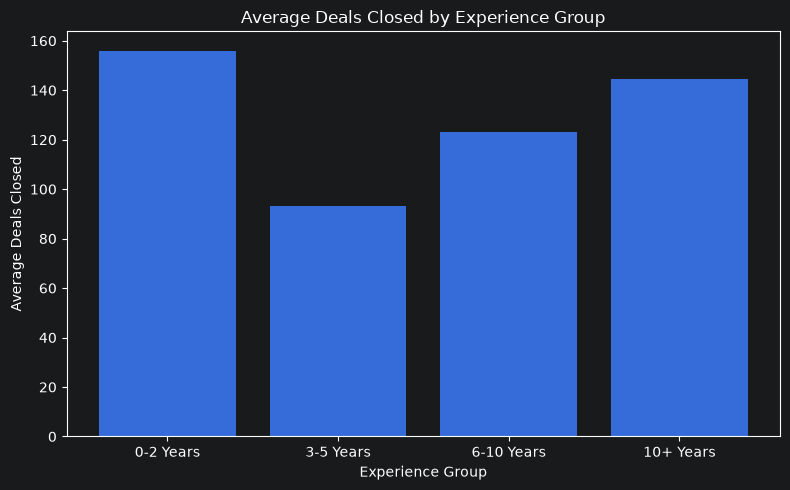

In [32]:
#Agent Performance
#22. Does experience correlate with deals closed?

#coding

query = """
SELECT
    agent_id,
    name,
    experience_years,
    deals_closed
FROM agents
ORDER BY experience_years ASC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

experience_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Experience (Years)",
        "Deals Closed"
    ]
)

print(experience_df)


#Calculate Correlation

correlation = experience_df["Experience (Years)"].corr(
    experience_df["Deals Closed"]
)

print("Correlation between Experience and Deals Closed:", round(correlation, 3))

#Interpretation
#Correlation ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ +1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Strong positive relationship (more experience, more deals closed).
#Correlation ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Little or no relationship.
#Correlation ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ -1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Negative relationship.


#Scatter Plot (Best Visualization)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    experience_df["Experience (Years)"],
    experience_df["Deals Closed"]
)

plt.title("Experience vs Deals Closed")
plt.xlabel("Experience (Years)")
plt.ylabel("Deals Closed")

plt.grid(True)

plt.tight_layout()
plt.show()


#Summary Analysis by Experience Group

query = """
SELECT
    CASE
        WHEN experience_years < 3 THEN '0-2 Years'
        WHEN experience_years BETWEEN 3 AND 5 THEN '3-5 Years'
        WHEN experience_years BETWEEN 6 AND 10 THEN '6-10 Years'
        ELSE '10+ Years'
    END AS experience_group,

    COUNT(*) AS total_agents,
    ROUND(AVG(deals_closed), 2) AS avg_deals_closed

FROM agents

GROUP BY experience_group

ORDER BY
CASE
    WHEN experience_group = '0-2 Years' THEN 1
    WHEN experience_group = '3-5 Years' THEN 2
    WHEN experience_group = '6-10 Years' THEN 3
    ELSE 4
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Summary

experience_group_df = pd.DataFrame(
    rows,
    columns=[
        "Experience Group",
        "Total Agents",
        "Average Deals Closed"
    ]
)

print(experience_group_df)


#Visualization- Bar Chart

plt.figure(figsize=(8,5))

plt.bar(
    experience_group_df["Experience Group"],
    experience_group_df["Average Deals Closed"]
)

plt.title("Average Deals Closed by Experience Group")
plt.xlabel("Experience Group")
plt.ylabel("Average Deals Closed")

plt.tight_layout()
plt.show()

('A0026', 'Agent A0026', Decimal('5.00'), 12, Decimal('49.50'))
('A0020', 'Agent A0020', Decimal('5.00'), 10, Decimal('62.30'))
('A0011', 'Agent A0011', Decimal('4.90'), 24, Decimal('64.71'))
('A0006', 'Agent A0006', Decimal('4.90'), 15, Decimal('81.33'))
('A0013', 'Agent A0013', Decimal('4.80'), 7, Decimal('42.43'))
('A0040', 'Agent A0040', Decimal('4.80'), 13, Decimal('55.92'))
('A0029', 'Agent A0029', Decimal('4.80'), 18, Decimal('62.00'))
('A0016', 'Agent A0016', Decimal('4.80'), 15, Decimal('64.53'))
('A0027', 'Agent A0027', Decimal('4.60'), 18, Decimal('61.33'))
('A0004', 'Agent A0004', Decimal('4.50'), 11, Decimal('80.09'))
('A0009', 'Agent A0009', Decimal('4.40'), 17, Decimal('52.71'))
('A0017', 'Agent A0017', Decimal('4.30'), 14, Decimal('48.57'))
('A0001', 'Agent A0001', Decimal('4.30'), 15, Decimal('61.93'))
('A0005', 'Agent A0005', Decimal('4.30'), 10, Decimal('63.90'))
('A0042', 'Agent A0042', Decimal('4.30'), 25, Decimal('67.00'))
('A0038', 'Agent A0038', Decimal('4.30'),

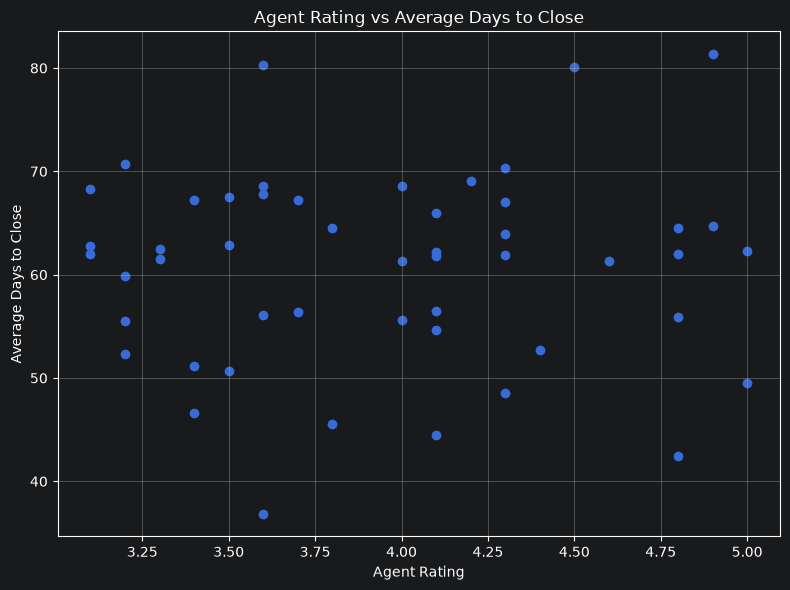

('Excellent (4.5-5.0)', 143, Decimal('63.52'))
('Good (4.0-4.49)', 226, Decimal('60.82'))
('Average (3.5-3.99)', 177, Decimal('62.57'))
('Below Average (<3.5)', 174, Decimal('60.22'))
        Rating Category  Total Agents Average Days to Close
0   Excellent (4.5-5.0)           143                 63.52
1       Good (4.0-4.49)           226                 60.82
2    Average (3.5-3.99)           177                 62.57
3  Below Average (<3.5)           174                 60.22


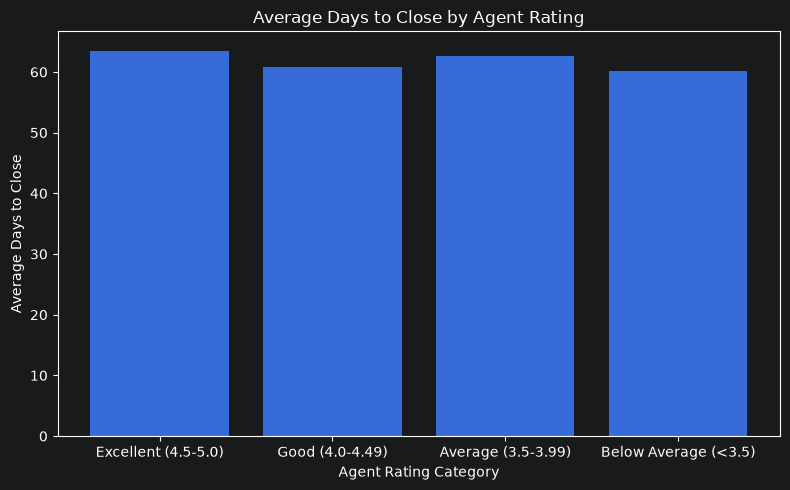

In [33]:
#Agent Performance
#23. Do agents with higher ratings close deals faster?


#coding

query = """
SELECT
    a.agent_id,
    a.name,
    a.rating,
    COUNT(s.listing_id) AS total_sales,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_to_close
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY a.agent_id, a.name, a.rating
ORDER BY a.rating DESC, avg_days_to_close ASC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

rating_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Rating",
        "Total Sales",
        "Average Days to Close"
    ]
)

print(rating_df)


#Calculate Correlation

correlation = rating_df["Rating"].corr(
    rating_df["Average Days to Close"]
)

print("Correlation:", round(correlation, 3))

#Interpretation
#Negative correlation (< 0): Higher-rated agents generally close deals faster.
#Positive correlation (> 0): Higher-rated agents tend to take longer to close deals.
#Near 0: Little or no relationship between ratings and closing speed.


#Scatter Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rating_df["Rating"],
    rating_df["Average Days to Close"]
)

plt.title("Agent Rating vs Average Days to Close")
plt.xlabel("Agent Rating")
plt.ylabel("Average Days to Close")

plt.grid(True)

plt.tight_layout()
plt.show()


#Group Ratings into Categories

query = """
SELECT
    CASE
        WHEN rating >= 4.5 THEN 'Excellent (4.5-5.0)'
        WHEN rating >= 4.0 THEN 'Good (4.0-4.49)'
        WHEN rating >= 3.5 THEN 'Average (3.5-3.99)'
        ELSE 'Below Average (<3.5)'
    END AS rating_category,

    COUNT(*) AS total_agents,
    ROUND(AVG(s.days_on_market), 2) AS avg_days_to_close

FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id

GROUP BY rating_category

ORDER BY
CASE
    WHEN rating_category = 'Excellent (4.5-5.0)' THEN 1
    WHEN rating_category = 'Good (4.0-4.49)' THEN 2
    WHEN rating_category = 'Average (3.5-3.99)' THEN 3
    ELSE 4
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Grouped Results

rating_group_df = pd.DataFrame(
    rows,
    columns=[
        "Rating Category",
        "Total Agents",
        "Average Days to Close"
    ]
)

print(rating_group_df)


#Visualization

plt.figure(figsize=(8,5))

plt.bar(
    rating_group_df["Rating Category"],
    rating_group_df["Average Days to Close"]
)

plt.title("Average Days to Close by Agent Rating")
plt.xlabel("Agent Rating Category")
plt.ylabel("Average Days to Close")

plt.tight_layout()
plt.show()

('A0009', 'Agent A0009', Decimal('2.85'), 17, Decimal('1192898.53'), Decimal('33997.61'))
('A0002', 'Agent A0002', Decimal('2.20'), 8, Decimal('1469370.75'), Decimal('32326.16'))
('A0035', 'Agent A0035', Decimal('2.96'), 21, Decimal('1082178.67'), Decimal('32032.49'))
('A0012', 'Agent A0012', Decimal('2.37'), 11, Decimal('1339139.54'), Decimal('31737.61'))
('A0030', 'Agent A0030', Decimal('2.79'), 11, Decimal('1134949.54'), Decimal('31665.09'))
('A0018', 'Agent A0018', Decimal('2.63'), 13, Decimal('1195375.08'), Decimal('31438.36'))
('A0031', 'Agent A0031', Decimal('2.51'), 13, Decimal('1209484.08'), Decimal('30358.05'))
('A0050', 'Agent A0050', Decimal('2.56'), 17, Decimal('1115796.94'), Decimal('28564.40'))
('A0017', 'Agent A0017', Decimal('2.14'), 14, Decimal('1327417.93'), Decimal('28406.74'))
('A0024', 'Agent A0024', Decimal('2.95'), 14, Decimal('942572.72'), Decimal('27805.90'))
('A0003', 'Agent A0003', Decimal('2.85'), 16, Decimal('974059.63'), Decimal('27760.70'))
('A0019', 'Ag

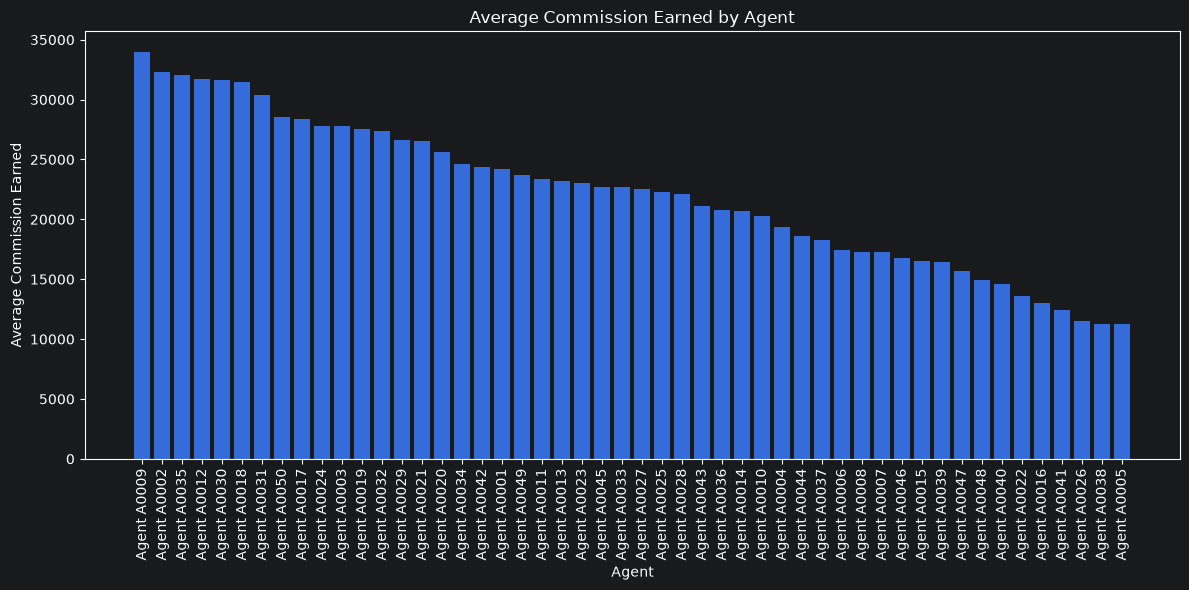

('A0035', 'Agent A0035', 21, Decimal('672682.26'))
('A0042', 'Agent A0042', 25, Decimal('609091.97'))
('A0009', 'Agent A0009', 17, Decimal('577959.34'))
('A0011', 'Agent A0011', 24, Decimal('560433.67'))
('A0050', 'Agent A0050', 17, Decimal('485594.83'))
('A0029', 'Agent A0029', 18, Decimal('479869.20'))
('A0019', 'Agent A0019', 17, Decimal('468457.13'))
('A0021', 'Agent A0021', 17, Decimal('451768.81'))
('A0003', 'Agent A0003', 16, Decimal('444171.19'))
('A0014', 'Agent A0014', 21, Decimal('434069.96'))
('A0043', 'Agent A0043', 20, Decimal('421792.32'))
('A0018', 'Agent A0018', 13, Decimal('408698.74'))
('A0027', 'Agent A0027', 18, Decimal('405114.18'))
('A0017', 'Agent A0017', 14, Decimal('397694.41'))
('A0031', 'Agent A0031', 13, Decimal('394654.65'))
('A0024', 'Agent A0024', 14, Decimal('389282.53'))
('A0025', 'Agent A0025', 17, Decimal('378253.68'))
('A0033', 'Agent A0033', 16, Decimal('363575.01'))
('A0001', 'Agent A0001', 15, Decimal('363478.40'))
('A0012', 'Agent A0012', 11, De

In [35]:
#Agent Performance
#24. What is the average commission earned by each agent?

#coding

query = """
SELECT
    a.agent_id,
    a.name,
    a.commission_rate,
    COUNT(s.listing_id) AS total_sales_closed,
    ROUND(AVG(s.sale_price), 2) AS average_sale_price,
    ROUND(AVG(s.sale_price * (a.commission_rate / 100)), 2) AS average_commission_earned
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY
    a.agent_id,
    a.name,
    a.commission_rate
ORDER BY average_commission_earned DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

commission_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Commission Rate (%)",
        "Total Sales Closed",
        "Average Sale Price",
        "Average Commission Earned"
    ]
)

print(commission_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    commission_df["Agent Name"],
    commission_df["Average Commission Earned"]
)

plt.title("Average Commission Earned by Agent")
plt.xlabel("Agent")
plt.ylabel("Average Commission Earned")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


#Total Commission Earned by Each Agent- total commission instead of the average, use:(additional part)

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(s.listing_id) AS total_sales_closed,
    ROUND(SUM(s.sale_price * (a.commission_rate / 100)), 2) AS total_commission_earned
FROM agents a
JOIN listings l
ON a.agent_id = l.agent_id
JOIN sales s
ON l.listing_id = s.listing_id
GROUP BY
    a.agent_id,
    a.name
ORDER BY total_commission_earned DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

('A0023', 'Agent A0023', 446)
('A0011', 'Agent A0011', 439)
('A0008', 'Agent A0008', 438)
('A0042', 'Agent A0042', 435)
('A0014', 'Agent A0014', 432)
('A0044', 'Agent A0044', 430)
('A0020', 'Agent A0020', 426)
('A0048', 'Agent A0048', 425)
('A0012', 'Agent A0012', 425)
('A0015', 'Agent A0015', 425)
('A0016', 'Agent A0016', 424)
('A0018', 'Agent A0018', 422)
('A0036', 'Agent A0036', 422)
('A0031', 'Agent A0031', 422)
('A0033', 'Agent A0033', 418)
('A0022', 'Agent A0022', 417)
('A0040', 'Agent A0040', 416)
('A0027', 'Agent A0027', 415)
('A0010', 'Agent A0010', 415)
('A0002', 'Agent A0002', 414)
('A0037', 'Agent A0037', 413)
('A0026', 'Agent A0026', 412)
('A0005', 'Agent A0005', 412)
('A0007', 'Agent A0007', 411)
('A0045', 'Agent A0045', 410)
('A0035', 'Agent A0035', 410)
('A0021', 'Agent A0021', 409)
('A0009', 'Agent A0009', 409)
('A0050', 'Agent A0050', 409)
('A0043', 'Agent A0043', 408)
('A0028', 'Agent A0028', 407)
('A0004', 'Agent A0004', 406)
('A0032', 'Agent A0032', 404)
('A0047', 

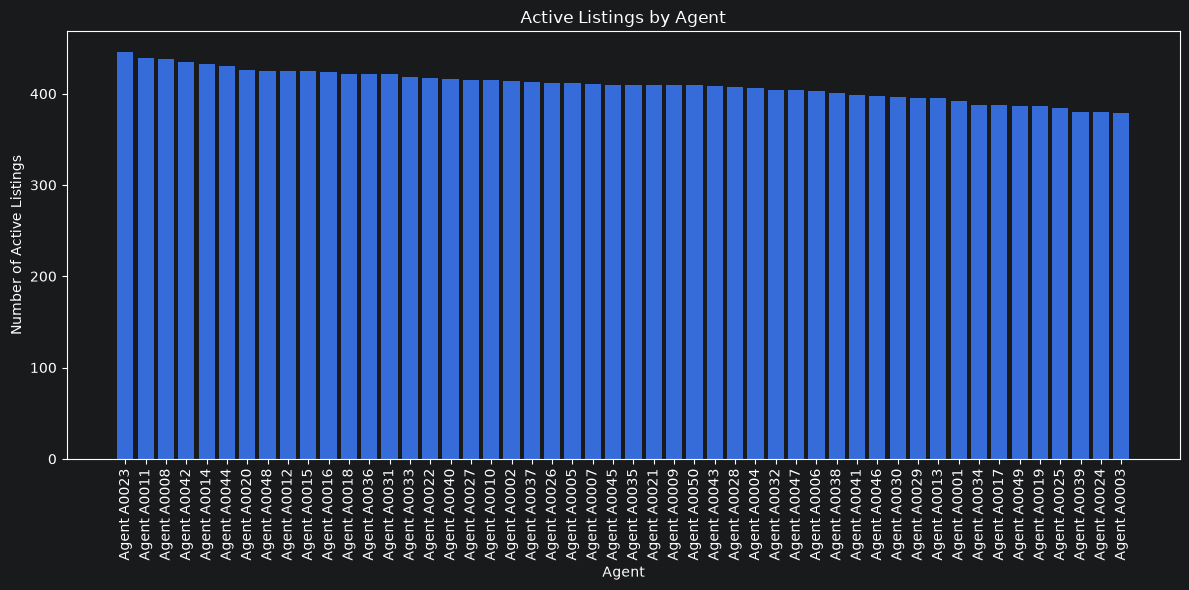

('A0023', 'Agent A0023', 446)
('A0011', 'Agent A0011', 439)
('A0008', 'Agent A0008', 438)
('A0042', 'Agent A0042', 435)
('A0014', 'Agent A0014', 432)
('A0044', 'Agent A0044', 430)
('A0020', 'Agent A0020', 426)
('A0012', 'Agent A0012', 425)
('A0015', 'Agent A0015', 425)
('A0048', 'Agent A0048', 425)


In [36]:
#Agent Performance
#25. Which agents currently have the most active listings?


# coding

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(l.listing_id) AS active_listings
FROM agents a
JOIN listings l
    ON a.agent_id = l.agent_id
LEFT JOIN sales s
    ON l.listing_id = s.listing_id
WHERE s.listing_id IS NULL
GROUP BY
    a.agent_id,
    a.name
ORDER BY active_listings DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

active_listing_df = pd.DataFrame(
    rows,
    columns=[
        "Agent ID",
        "Agent Name",
        "Active Listings"
    ]
)

print(active_listing_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    active_listing_df["Agent Name"],
    active_listing_df["Active Listings"]
)

plt.title("Active Listings by Agent")
plt.xlabel("Agent")
plt.ylabel("Number of Active Listings")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


#Top 10 Agents with the Most Active Listings

query = """
SELECT
    a.agent_id,
    a.name,
    COUNT(l.listing_id) AS active_listings
FROM agents a
JOIN listings l
    ON a.agent_id = l.agent_id
LEFT JOIN sales s
    ON l.listing_id = s.listing_id
WHERE s.listing_id IS NULL
GROUP BY
    a.agent_id,
    a.name
ORDER BY active_listings DESC
LIMIT 10;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

('End User', 10020, Decimal('50.10'))
('Investor', 9980, Decimal('49.90'))
  Buyer Type  Total Buyers Percentage (%)
0   End User         10020          50.10
1   Investor          9980          49.90


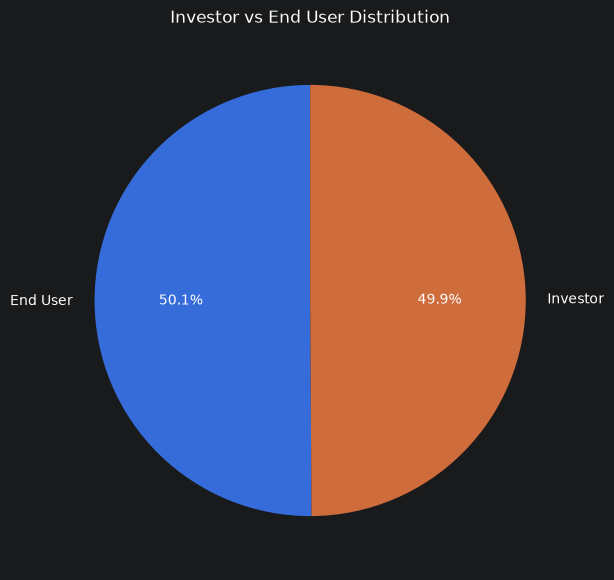

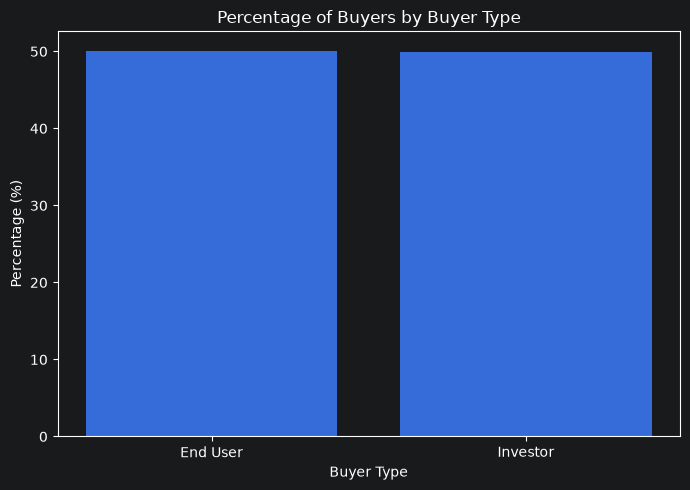

In [37]:
# Buyer & Financing Behavior
# 26. What percentage of buyers are investors vs end users?

#Coding

query = """
SELECT
    buyer_type,
    COUNT(*) AS total_buyers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM buyers), 2) AS percentage
FROM buyers
GROUP BY buyer_type
ORDER BY percentage DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results in a Pandas DataFrame

import pandas as pd

buyer_type_df = pd.DataFrame(
    rows,
    columns=[
        "Buyer Type",
        "Total Buyers",
        "Percentage (%)"
    ]
)

print(buyer_type_df)


#Visualization (Pie Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    buyer_type_df["Total Buyers"],
    labels=buyer_type_df["Buyer Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor vs End User Distribution")

plt.show()


#Visualization (Bar Chart)

plt.figure(figsize=(7,5))

plt.bar(
    buyer_type_df["Buyer Type"],
    buyer_type_df["Percentage (%)"]
)

plt.title("Percentage of Buyers by Buyer Type")
plt.xlabel("Buyer Type")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

('Chicago', 3120000, Decimal('1565304'), Decimal('50.17'))
('Los Angeles', 2560000, Decimal('1284352'), Decimal('50.17'))
('Houston', 2620000, Decimal('1314454'), Decimal('50.17'))
('New York', 2740000, Decimal('1374658'), Decimal('50.17'))
('Phoenix', 3360000, Decimal('1685712'), Decimal('50.17'))
          City  Total Buyers Buyers with Loan Loan Uptake Rate (%)
0      Chicago       3120000          1565304                50.17
1  Los Angeles       2560000          1284352                50.17
2      Houston       2620000          1314454                50.17
3     New York       2740000          1374658                50.17
4      Phoenix       3360000          1685712                50.17


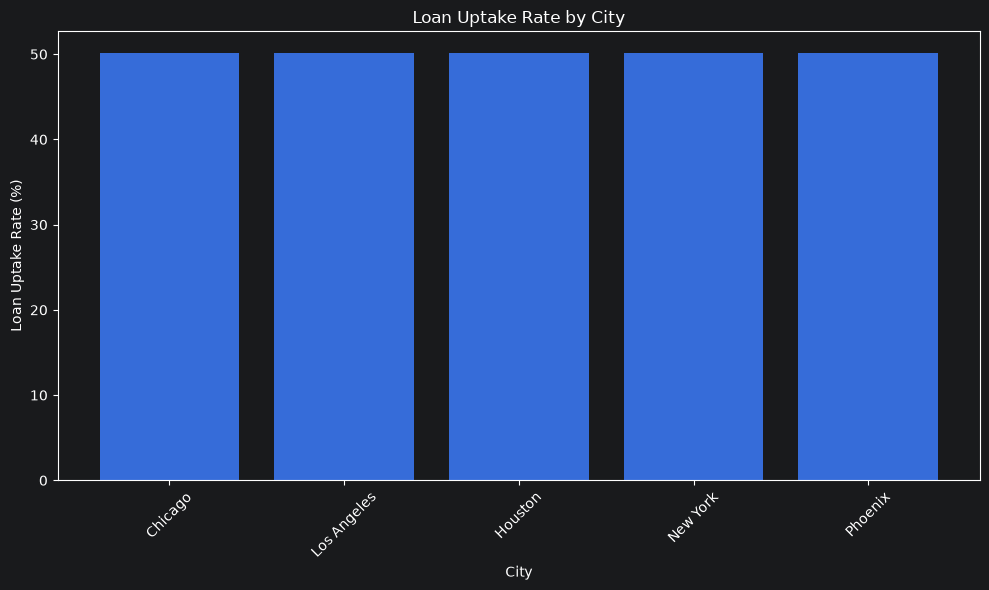

In [38]:
# Buyer & Financing Behavior
# 27. Which cities have the highest loan uptake rate?


#coding

query = """
SELECT
    l.city,
    COUNT(b.buyer_id) AS total_buyers,
    SUM(CASE
            WHEN b.loan_taken = TRUE THEN 1
            ELSE 0
        END) AS buyers_with_loan,
    ROUND(
        SUM(CASE
                WHEN b.loan_taken = TRUE THEN 1
                ELSE 0
            END) * 100.0 / COUNT(b.buyer_id),
        2
    ) AS loan_uptake_rate
FROM buyers b
JOIN sales s
    ON b.sale_id = b.sale_id
JOIN listings l
    ON s.listing_id = l.listing_id
GROUP BY l.city
ORDER BY loan_uptake_rate DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results Using Pandas

import pandas as pd

loan_city_df = pd.DataFrame(
    rows,
    columns=[
        "City",
        "Total Buyers",
        "Buyers with Loan",
        "Loan Uptake Rate (%)"
    ]
)

print(loan_city_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    loan_city_df["City"],
    loan_city_df["Loan Uptake Rate (%)"]
)

plt.title("Loan Uptake Rate by City")
plt.xlabel("City")
plt.ylabel("Loan Uptake Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

('Investor', 9980, 9980, Decimal('2629271.94'))
('End User', 10020, 10020, Decimal('2599433.82'))
  Buyer Type  Total Buyers  Buyers with Loan Average Loan Amount
0   Investor          9980              9980          2629271.94
1   End User         10020             10020          2599433.82


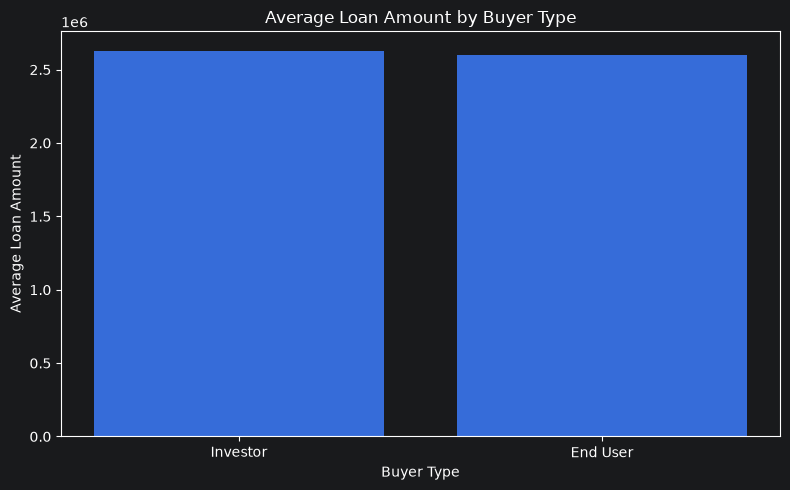

('Investor', 9980, Decimal('5035'), Decimal('5211545.97'))
('End User', 10020, Decimal('4999'), Decimal('5210307.45'))


In [39]:
# Buyer & Financing Behavior
# 28. What is the average loan amount by buyer type?



#coding

query = """
SELECT
    buyer_type,
    COUNT(*) AS total_buyers,
    COUNT(loan_amount) AS buyers_with_loan,
    ROUND(AVG(loan_amount), 2) AS average_loan_amount
FROM buyers
WHERE loan_amount IS NOT NULL
GROUP BY buyer_type
ORDER BY average_loan_amount DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results as a DataFrame

import pandas as pd

loan_df = pd.DataFrame(
    rows,
    columns=[
        "Buyer Type",
        "Total Buyers",
        "Buyers with Loan",
        "Average Loan Amount"
    ]
)

print(loan_df)


#Visualization (Bar Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    loan_df["Buyer Type"],
    loan_df["Average Loan Amount"]
)

plt.title("Average Loan Amount by Buyer Type")
plt.xlabel("Buyer Type")
plt.ylabel("Average Loan Amount")

plt.tight_layout()
plt.show()


#Include Buyer Types Without Loans - all buyer types (even those with no loans), use:

query = """
SELECT
    buyer_type,
    COUNT(*) AS total_buyers,
    SUM(CASE
            WHEN loan_taken = TRUE THEN 1
            ELSE 0
        END) AS buyers_with_loan,
    ROUND(AVG(
        CASE
            WHEN loan_taken = TRUE THEN loan_amount
            ELSE NULL
        END
    ), 2) AS average_loan_amount
FROM buyers
GROUP BY buyer_type
ORDER BY average_loan_amount DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

('Cash', 5088, Decimal('25.44'))
('UPI', 5012, Decimal('25.06'))
('Cheque', 4951, Decimal('24.76'))
('Bank Transfer', 4949, Decimal('24.75'))
    Payment Mode  Total Transactions Percentage (%)
0           Cash                5088          25.44
1            UPI                5012          25.06
2         Cheque                4951          24.76
3  Bank Transfer                4949          24.75


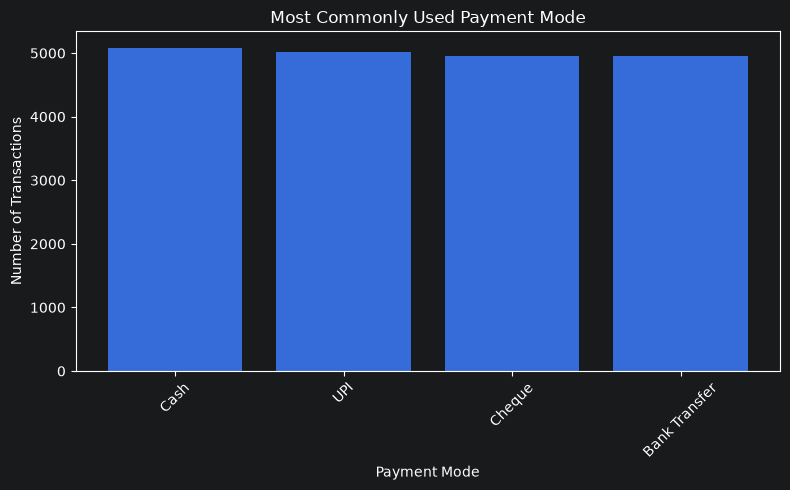

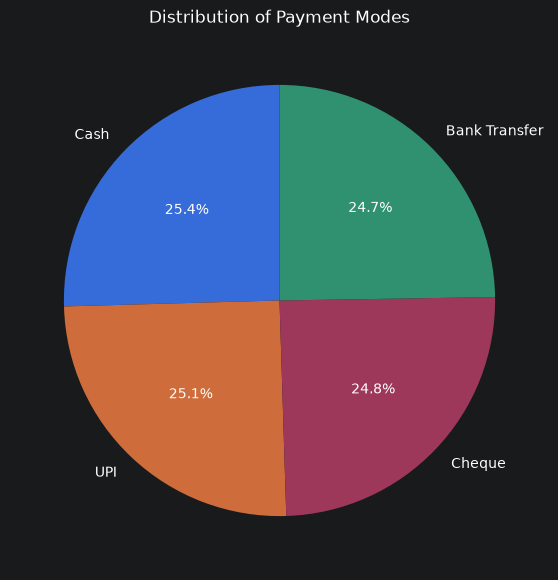

Most Common Payment Mode: Cash
Number of Transactions: 5088


In [40]:
#Buyer & Financing Behavior
# 29. Which payment mode is most commonly used?


#Coding

query = """
SELECT
    payment_mode,
    COUNT(*) AS total_transactions,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM buyers),
        2
    ) AS percentage
FROM buyers
GROUP BY payment_mode
ORDER BY total_transactions DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results as a DataFrame

import pandas as pd

payment_df = pd.DataFrame(
    rows,
    columns=[
        "Payment Mode",
        "Total Transactions",
        "Percentage (%)"
    ]
)

print(payment_df)


#Visualization (Bar Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    payment_df["Payment Mode"],
    payment_df["Total Transactions"]
)

plt.title("Most Commonly Used Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Visualization (Pie Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    payment_df["Total Transactions"],
    labels=payment_df["Payment Mode"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Payment Modes")

plt.show()


#Find Only the Most Common Payment Mode- the single most frequently used payment mode:

query = """
SELECT
    payment_mode,
    COUNT(*) AS total_transactions
FROM buyers
GROUP BY payment_mode
ORDER BY total_transactions DESC
LIMIT 1;
"""

cursor.execute(query)

result = cursor.fetchone()

print("Most Common Payment Mode:", result[0])
print("Number of Transactions:", result[1])

('No Loan', 7175520, Decimal('61.64'))
('Loan Taken', 7224480, Decimal('61.64'))
  Loan Status  Total Purchases Average Days to Close
0     No Loan          7175520                 61.64
1  Loan Taken          7224480                 61.64


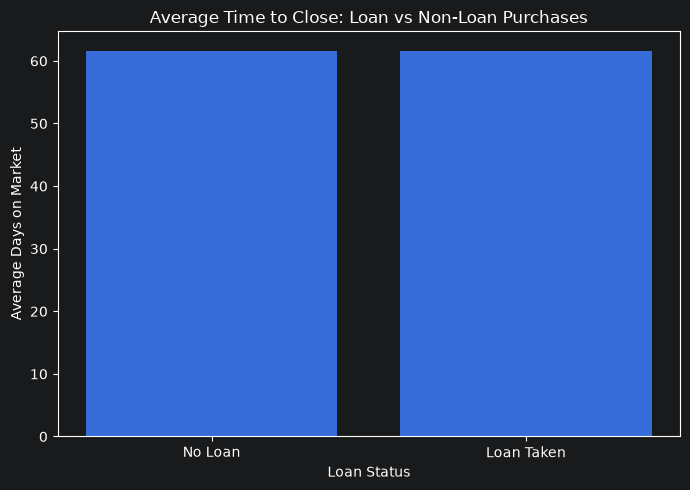

In [41]:
#Buyer & Financing Behavior
#30. Do loan-backed purchases take longer to close?

query = """
SELECT
    CASE
        WHEN b.loan_taken = TRUE THEN 'Loan Taken'
        ELSE 'No Loan'
    END AS loan_status,

    COUNT(*) AS total_purchases,

    ROUND(AVG(s.days_on_market), 2) AS avg_days_to_close

FROM buyers b
JOIN sales s
ON b.sale_id = b.sale_id

GROUP BY loan_status
ORDER BY avg_days_to_close DESC;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)


#Display Results as a DataFrame

import pandas as pd

loan_close_df = pd.DataFrame(
    rows,
    columns=[
        "Loan Status",
        "Total Purchases",
        "Average Days to Close"
    ]
)

print(loan_close_df)


#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    loan_close_df["Loan Status"],
    loan_close_df["Average Days to Close"]
)

plt.title("Average Time to Close: Loan vs Non-Loan Purchases")
plt.xlabel("Loan Status")
plt.ylabel("Average Days on Market")

plt.tight_layout()
plt.show()